# From Automotive AI to Generative AI: The Changing Semiconductor Value Chain
## Seven additional presentation figures (8-14)

This notebook reuses processed data and leaves previous notebooks, CSVs, and original financial values unchanged. Pandas performs grouping, reshaping, joins, and validation; Matplotlib performs plotting, annotation, formatting, and PNG/PDF export. NumPy, Seaborn, and Plotly are not needed for this requested figure set.

**Instruction reconciliation:** The detailed list numbers the additional figures 8-14, which is followed here. Figure 13 explicitly requires October 2024-April 2026 and is the sole source-review exception to the 2024 cutoff. All financial conclusions end in 2024.

**Analytical periods:** 2010-2021 Smart automobile expansion; 2022 Transition Year; 2023-2024 Generative AI expansion. These are project labels, not evidence of technological causation. They are assigned to an in-memory copy; existing period columns are not overwritten on disk.

In [1]:
from pathlib import Path
import hashlib
import json
import math
import textwrap
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import StrMethodFormatter, PercentFormatter, MaxNLocator
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from PIL import Image as PILImage
from IPython.display import display, Markdown, Image

ROOT = Path.cwd() if (Path.cwd() / 'data/raw').is_dir() else Path.cwd().parent
FIG = ROOT / 'figures/final'
OUT = ROOT / 'outputs/final_visualizations'
FIG.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)
protected = list((ROOT/'data').rglob('*.csv')) + list((ROOT/'outputs/supporting_data_eda/clean').glob('*.csv')) + [p for p in (ROOT/'notebooks').glob('*.ipynb') if p.name != '07_final_presentation_visualizations.ipynb']
before_hashes = {str(p.relative_to(ROOT)): hashlib.sha256(p.read_bytes()).hexdigest() for p in protected}
financials = pd.read_csv(ROOT/'data/processed/financials_features.csv')
support = ROOT/'outputs/supporting_data_eda/clean'
ai = pd.read_csv(support/'ai_chip_market_clean.csv')
prices = pd.read_csv(support/'chip_prices_clean.csv', parse_dates=['month_date'])
capacity = pd.read_csv(support/'fab_capacity_clean.csv')
events = pd.read_csv(support/'export_controls_clean.csv')
assert not financials.duplicated(['company_name','year']).any()
assert not ai.duplicated(['vendor','chip_name','year']).any()
assert not prices.duplicated(['product','year_month','currency','unit']).any()
assert not capacity.duplicated(['year','company','country_iso3','process_node_nm','fab_type']).any()
assert not events.control_id.duplicated().any()
fin = financials.loc[financials.year.between(2010,2024)].copy()
PERIODS = ['Smart automobile expansion','Transition Year','Generative AI expansion']
fin['presentation_period'] = pd.cut(fin.year, bins=[2009,2021,2022,2024], labels=PERIODS)
assert fin.presentation_period.notna().all()
GROUPS = ['Foundry','Fabless','IDM','Equipment','EDA Software']
COLORS = dict(zip(GROUPS,['#174A7E','#E88B25','#2E7D32','#7B4AB5','#C43C39']))
assert set(fin.value_chain_group)==set(GROUPS)
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white','savefig.facecolor':'white','savefig.transparent':False,'font.family':'DejaVu Sans','font.size':12,'axes.titlesize':13,'axes.labelsize':12,'xtick.labelsize':11,'ytick.labelsize':11,'legend.fontsize':10,'axes.spines.top':False,'axes.spines.right':False,'pdf.fonttype':42})
SOURCE = 'Source: supplied processed CSVs; author calculations.'
records=[]
findings=[]
chart_inputs={}

def style(ax,xlabel,ylabel,grid=True):
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_axisbelow(True)
    if grid: ax.grid(axis='y',color='#E3E7EB',linewidth=.7)
    ax.spines['left'].set_color('#BAC2C9'); ax.spines['bottom'].set_color('#BAC2C9')
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

def heading(fig,number,title,subtitle):
    fig.text(.065,.972,f'FIGURE {number}  |  {title}',ha='left',va='top',fontsize=19,fontweight='bold',color='#163247')
    fig.text(.065,.927,subtitle,ha='left',va='top',fontsize=11.5,color='#52616B')

def save(fig,number,slug,title,subtitle,note,maximum_year):
    heading(fig,number,title,subtitle)
    fig.text(.065,.035,textwrap.fill(SOURCE+' '+note,155),ha='left',va='bottom',fontsize=9,color='#52616B')
    fig.tight_layout(rect=[.035,.13,.985,.875])
    fig.canvas.draw()
    for ax in fig.axes:
        if ax.axison:
            assert ax.get_xlabel() and ax.get_ylabel(), f'Missing axis labels: {number}'
    for ext in ['png','pdf']:
        path=FIG/f'figure_{number:02d}_{slug}.{ext}'
        fig.savefig(path,dpi=300,facecolor='white',transparent=False)
        records.append({'figure':number,'file':str(path.relative_to(ROOT)),'format':ext,'maximum_year':maximum_year,'source_and_limitation_note':note,'title':title,'axes_labels_present':True,'background':'white'})
    display(Image(filename=str(FIG/f'figure_{number:02d}_{slug}.png'),width=1000))
    plt.close(fig)

def interpretation(number,finding,implication,action,limitation):
    findings.append({'Figure':number,'Main finding':finding,'Business implication':implication,'Possible action':action,'Limitation':limitation})
    display(Markdown(f'**Confirmed finding from the supplied data:** {finding}\n\n**Important limitation:** {limitation}\n\n**Possible action or decision use:** {action}'))

display(pd.DataFrame([{'Dataset':'Financial features','Rows':len(financials),'Historical rows plotted':len(fin)}, {'Dataset':'AI-chip estimates','Rows':len(ai)}, {'Dataset':'Monthly prices','Rows':len(prices)}, {'Dataset':'Capacity records','Rows':len(capacity)}, {'Dataset':'Policy events','Rows':len(events)}]))

,Dataset,Rows,Historical rows plotted
0,Financial features,617,537.0
1,AI-chip estimates,120,NaN
2,Monthly prices,405,NaN
3,Capacity records,313,NaN
4,Policy events,34,NaN


## Figure 8 - Financial revenue trend and coverage
**Question:** How did revenue represented in the financial dataset change, and how did entity coverage change alongside it?
Annual totals are grouped directly from unique entity-year records. The lower panel exposes changing coverage. Period shading is analytical context only.

In [2]:
trend = fin.groupby('year',as_index=False).agg(revenue_usd_bn=('revenue_usd_bn','sum'),entities=('company_name','nunique'))
trend['yoy_pct']=trend.revenue_usd_bn.pct_change(fill_method=None)*100
chart_inputs[8]=trend
display(trend.round(2))

,year,revenue_usd_bn,entities,yoy_pct
0,2010,235.00,33,NaN
1,2011,249.80,33,6.30
2,2012,266.67,33,6.75
3,2013,284.22,33,6.58
4,2014,292.77,33,3.01
5,2015,311.52,33,6.40
6,2016,369.27,33,18.54
7,2017,430.35,34,16.54
8,2018,476.20,35,10.65
9,2019,495.05,37,3.96


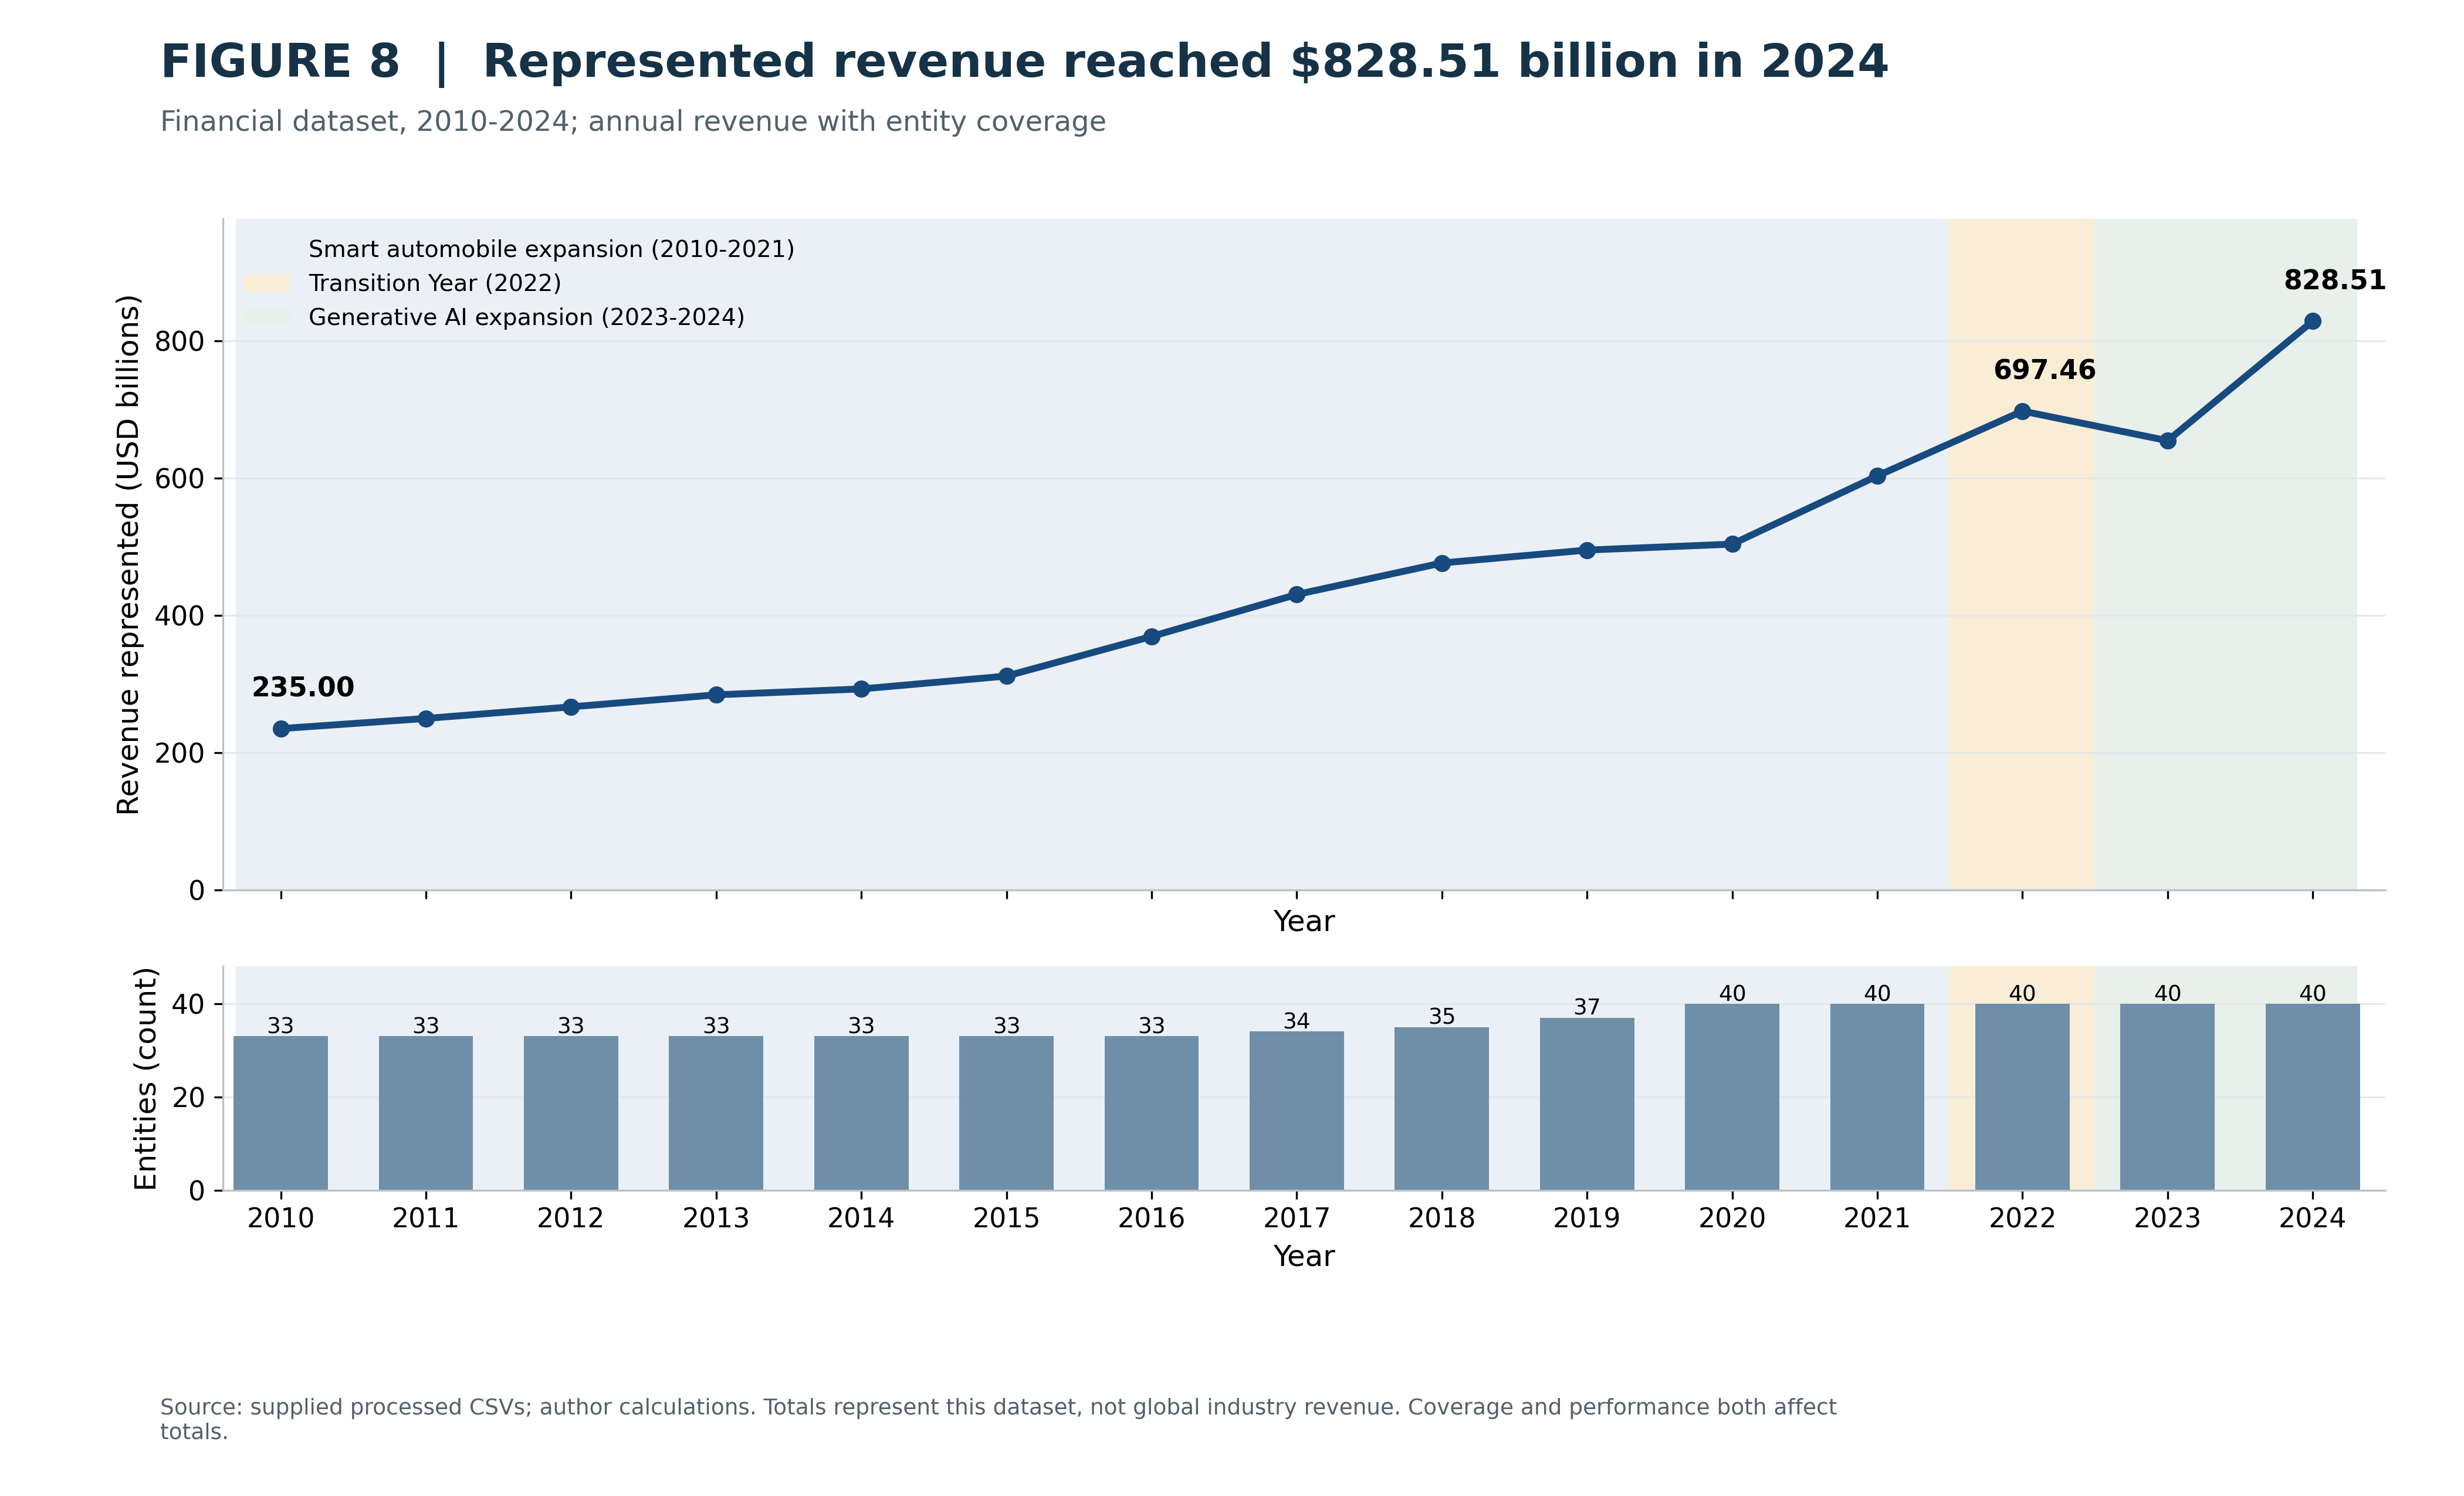

**Confirmed finding from the supplied data:** Revenue increased from $235.00bn in 2010 to $828.51bn in 2024; entity coverage increased from 33 to 40.

**Important limitation:** Dataset coverage changes; period labels do not establish causation.

**Possible action or decision use:** Compare the aggregate with a fixed-company panel before attributing changes to company performance.

In [3]:
fig,(top,bottom)=plt.subplots(2,1,figsize=(14,8.5),sharex=True,gridspec_kw={'height_ratios':[3,1]})
for ax in [top,bottom]:
    for lo,hi,color in [(2009.7,2021.5,'#EAF0F5'),(2021.5,2022.5,'#FAEDD6'),(2022.5,2024.3,'#E7F0EA')]: ax.axvspan(lo,hi,color=color,zorder=0)
top.plot(trend.year,trend.revenue_usd_bn,color='#174A7E',marker='o',lw=2.8)
for year in [2010,2022,2024]:
    row=trend.loc[trend.year.eq(year)].iloc[0]
    top.annotate(f'{row.revenue_usd_bn:,.2f}',(year,row.revenue_usd_bn),xytext=(-12,13),textcoords='offset points',fontsize=11,fontweight='bold')
top.set_ylim(0,trend.revenue_usd_bn.max()*1.18)
top.legend(handles=[Patch(facecolor='#EAF0F5',label='Smart automobile expansion (2010-2021)'),Patch(facecolor='#FAEDD6',label='Transition Year (2022)'),Patch(facecolor='#E7F0EA',label='Generative AI expansion (2023-2024)')],loc='upper left',frameon=False,fontsize=9.5)
bottom.bar(trend.year,trend.entities,color='#6F8FA9',width=.65)
for x,y in zip(trend.year,trend.entities): bottom.text(x,y+.6,str(y),ha='center',fontsize=9)
bottom.set_ylim(0,48); bottom.set_xticks(trend.year); bottom.set_xlim(2009.6,2024.5)
style(top,'Year','Revenue represented (USD billions)'); style(bottom,'Year','Entities (count)')
save(fig,8,'financial_revenue_coverage','Represented revenue reached $828.51 billion in 2024','Financial dataset, 2010-2024; annual revenue with entity coverage', 'Totals represent this dataset, not global industry revenue. Coverage and performance both affect totals.',2024)
interpretation(8,f'Revenue increased from ${trend.iloc[0].revenue_usd_bn:,.2f}bn in 2010 to ${trend.iloc[-1].revenue_usd_bn:,.2f}bn in 2024; entity coverage increased from {int(trend.iloc[0].entities)} to {int(trend.iloc[-1].entities)}.','Aggregate growth includes a changing set of represented entities.','Compare the aggregate with a fixed-company panel before attributing changes to company performance.','Dataset coverage changes; period labels do not establish causation.')

## Figure 9 - Value-chain comparison across three periods
**Question:** How did average annual revenue differ across value-chain roles and analytical periods?
First sum revenue by group-year, then average annual totals within each period. The coverage table reports distinct entities in each group-period, not an annual headcount. No group-year is absent in this dataset.

In [4]:
group_year=fin.groupby(['year','value_chain_group','presentation_period'],observed=True,as_index=False).agg(revenue_usd_bn=('revenue_usd_bn','sum'),annual_entities=('company_name','nunique'))
assert len(group_year)==15*5
period_summary=group_year.groupby(['value_chain_group','presentation_period'],observed=True,as_index=False).agg(average_annual_revenue_usd_bn=('revenue_usd_bn','mean'),observed_years=('year','nunique'),minimum_annual_entities=('annual_entities','min'),maximum_annual_entities=('annual_entities','max'))
distinct=fin.groupby(['value_chain_group','presentation_period'],observed=True,as_index=False).company_name.nunique().rename(columns={'company_name':'distinct_entities'})
period_summary=period_summary.merge(distinct,on=['value_chain_group','presentation_period'],validate='one_to_one')
period_values=period_summary.pivot(index='value_chain_group',columns='presentation_period',values='average_annual_revenue_usd_bn').reindex(index=GROUPS,columns=PERIODS)
counts=period_summary.pivot(index='value_chain_group',columns='presentation_period',values='distinct_entities').reindex(index=GROUPS,columns=PERIODS)
change=(period_values[PERIODS[2]]/period_values[PERIODS[0]]-1)*100
chart_inputs[9]=period_summary
display(period_summary.round(2))

,value_chain_group,presentation_period,average_annual_revenue_usd_bn,observed_years,minimum_annual_entities,maximum_annual_entities,distinct_entities
0,EDA Software,Smart automobile expansion,4.42,12,2,2,2
1,EDA Software,Transition Year,8.34,1,2,2,2
2,EDA Software,Generative AI expansion,10.06,2,2,2,2
3,Equipment,Smart automobile expansion,44.43,12,6,6,6
4,Equipment,Transition Year,97.26,1,6,6,6
5,Equipment,Generative AI expansion,103.29,2,6,6,6
6,Fabless,Smart automobile expansion,65.40,12,7,12,12
7,Fabless,Transition Year,154.83,1,12,12,12
8,Fabless,Generative AI expansion,230.70,2,12,12,12
9,Foundry,Smart automobile expansion,52.64,12,6,6,6


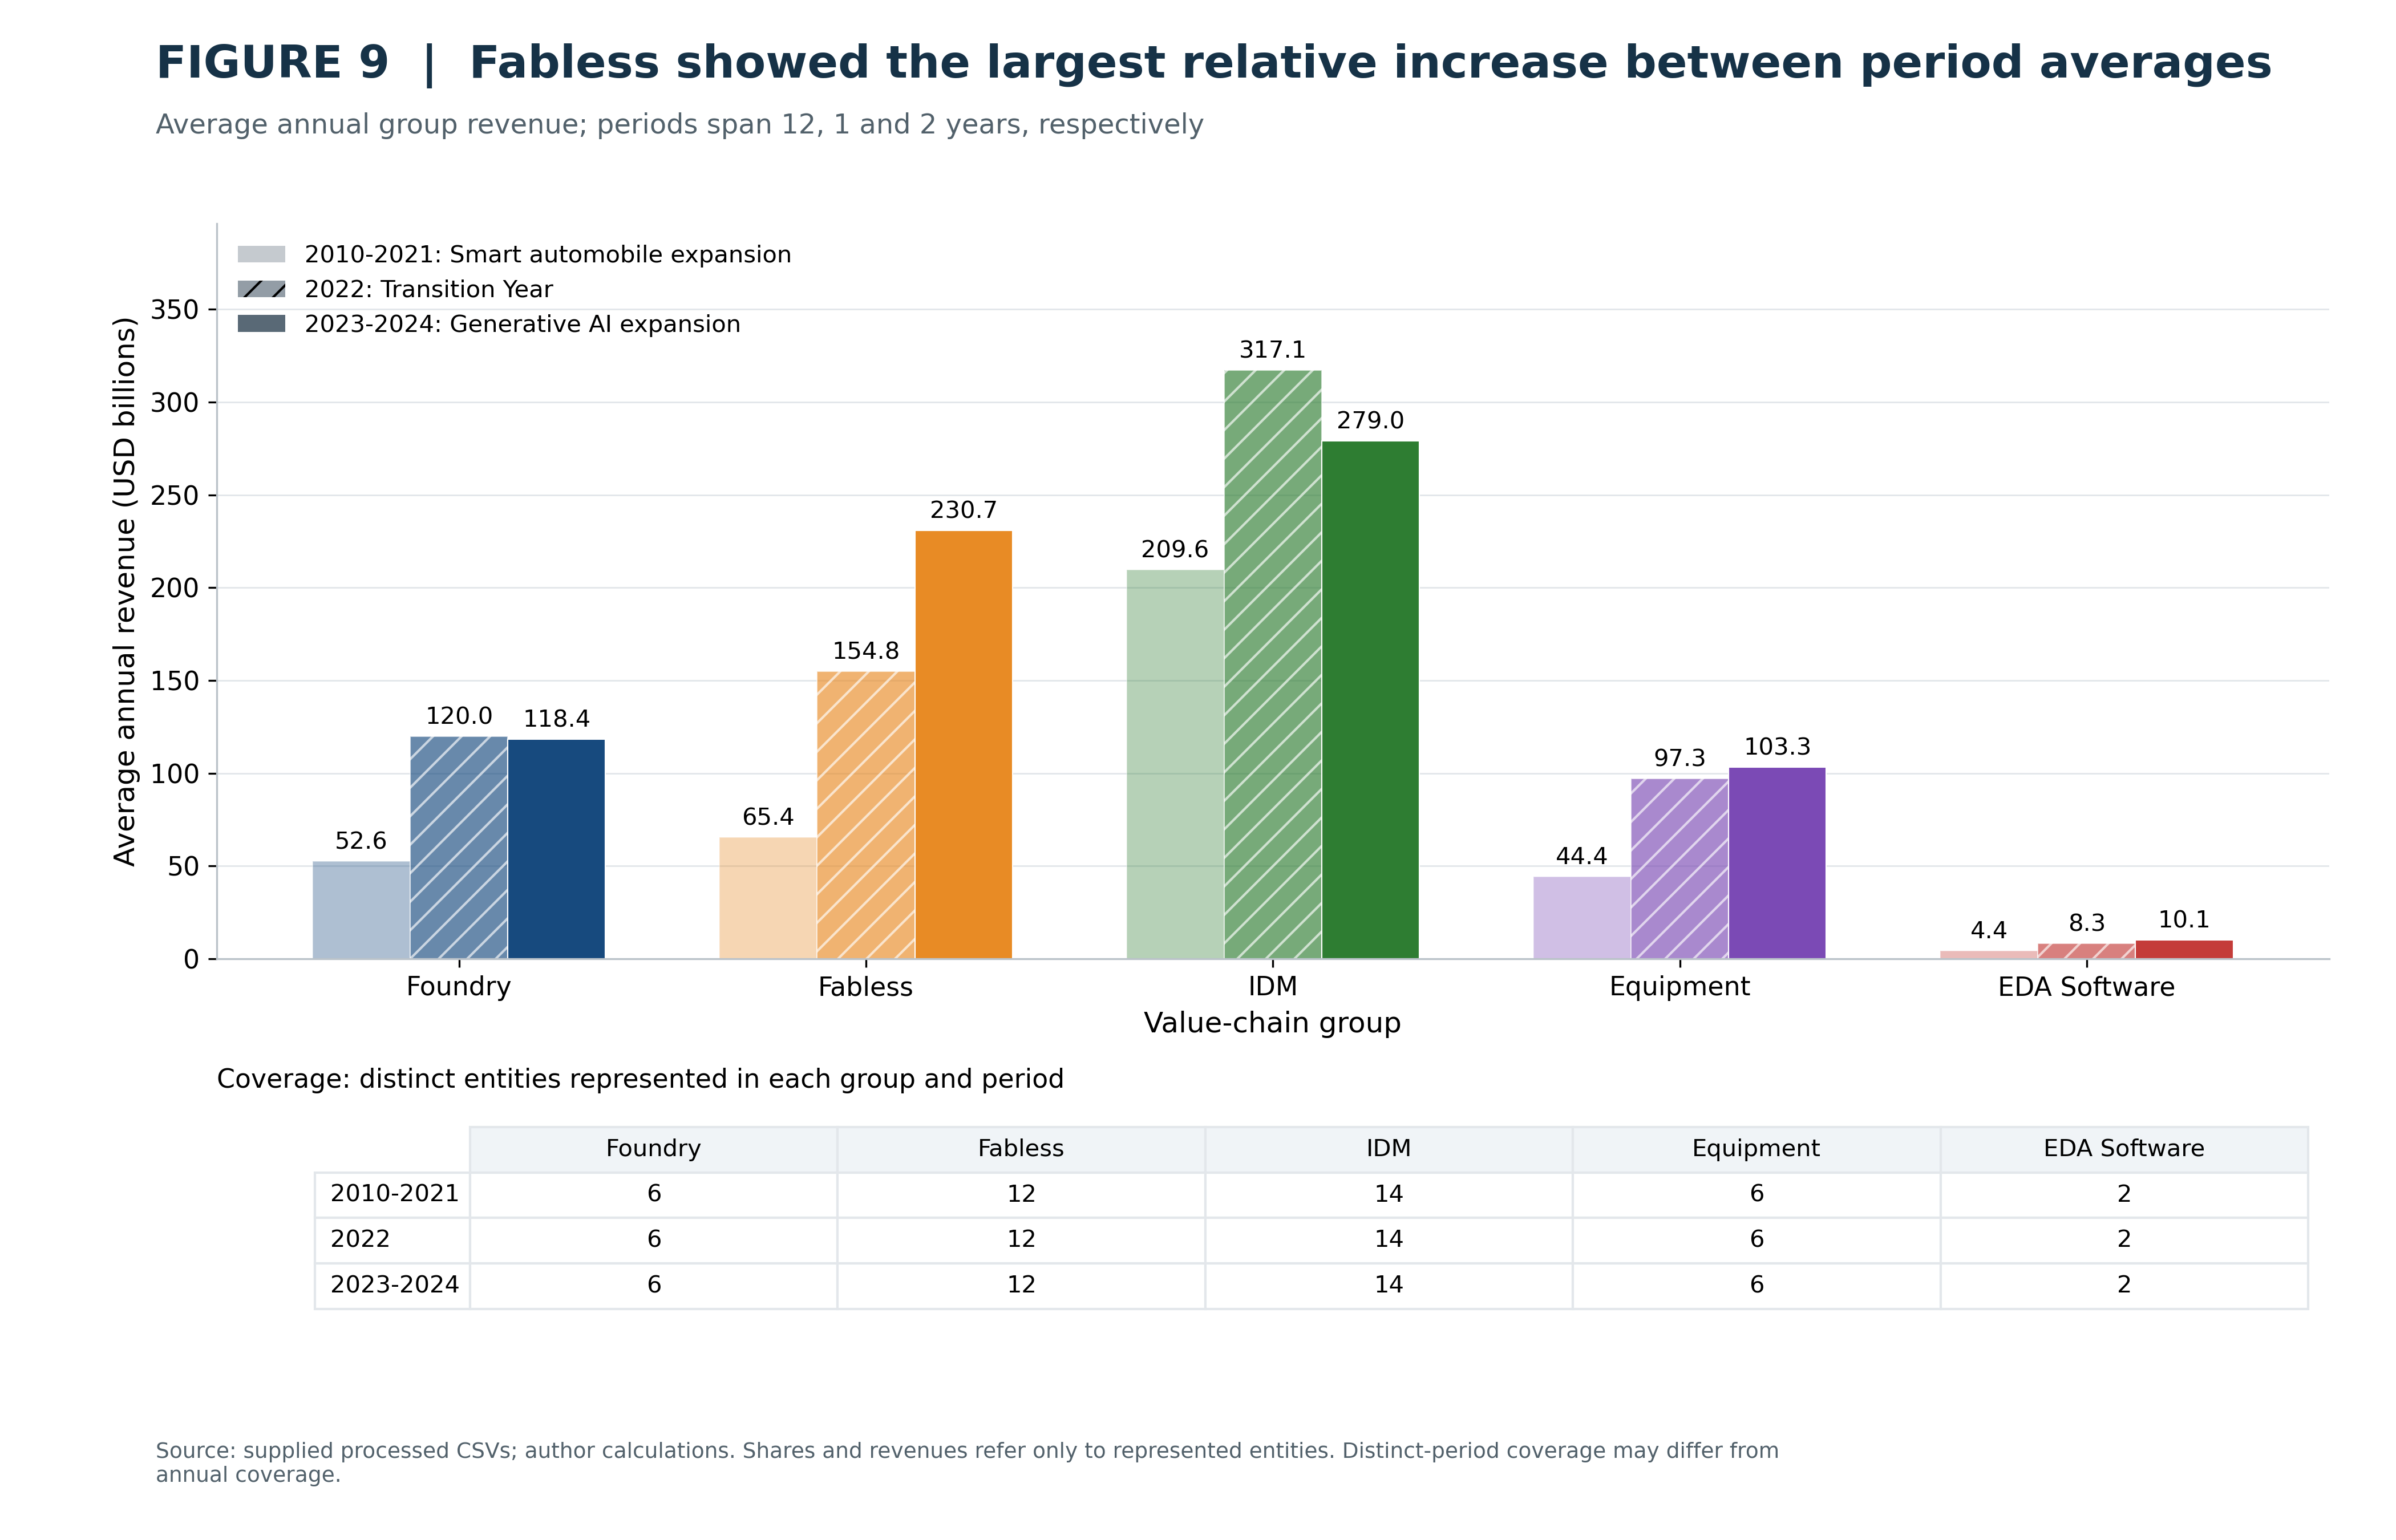

**Confirmed finding from the supplied data:** Fabless average annual revenue increased 252.8% between the first and third periods.

**Important limitation:** Unequal periods are addressed with annual averages, but changing entity coverage and long-run trends remain.

**Possible action or decision use:** Compare group margins and R&D/CapEx intensity alongside revenue; check a fixed-company comparison.

In [5]:
fig,(ax,table_ax)=plt.subplots(2,1,figsize=(14,9),gridspec_kw={'height_ratios':[4,1.1]})
x=list(range(5)); width=.24
for j,(period,alpha,hatch) in enumerate(zip(PERIODS,[.35,.65,1],['','//',''])):
    bars=ax.bar([v+(j-1)*width for v in x],period_values[period],width,color=[COLORS[g] for g in GROUPS],alpha=alpha,hatch=hatch,edgecolor='white',linewidth=.5)
    ax.bar_label(bars,fmt='%.1f',padding=3,fontsize=10)
ax.set_xticks(x,GROUPS); ax.set_ylim(0,period_values.max().max()*1.25)
ax.legend(handles=[Patch(facecolor='#596976',alpha=a,hatch=h,label=l) for a,h,l in zip([.35,.65,1],['','//',''],['2010-2021: Smart automobile expansion','2022: Transition Year','2023-2024: Generative AI expansion'])],frameon=False,loc='upper left',fontsize=10)
style(ax,'Value-chain group','Average annual revenue (USD billions)')
table_ax.axis('off'); table_ax.set_title('Coverage: distinct entities represented in each group and period',loc='left',fontsize=11,pad=8)
table=table_ax.table(cellText=[[int(counts.loc[g,p]) for g in GROUPS] for p in PERIODS],rowLabels=['2010-2021','2022','2023-2024'],colLabels=GROUPS,cellLoc='center',loc='center',bbox=[.12,0,.87,.9])
table.auto_set_font_size(False); table.set_fontsize(10)
for (r,c),cell in table.get_celld().items(): cell.set_edgecolor('#E3E7EB'); cell.set_facecolor('#F0F4F7' if r==0 else 'white')
save(fig,9,'value_chain_periods',f'{change.idxmax()} showed the largest relative increase between period averages','Average annual group revenue; periods span 12, 1 and 2 years, respectively','Shares and revenues refer only to represented entities. Distinct-period coverage may differ from annual coverage.',2024)
interpretation(9,f'{change.idxmax()} average annual revenue increased {change.max():.1f}% between the first and third periods.','Value-chain roles had different revenue trajectories.','Compare group margins and R&D/CapEx intensity alongside revenue; check a fixed-company comparison.','Unequal periods are addressed with annual averages, but changing entity coverage and long-run trends remain.')

## Figure 10 - Company revenue growth, 2022-2024
**Question:** Which ten companies recorded the largest absolute revenue increases?
Only companies with positive revenue at both endpoints qualify. Endpoint markers and dollar changes preserve starting-size context; this is not a percentage-growth ranking.

In [6]:
endpoints=fin.loc[fin.year.isin([2022,2024])].pivot(index='company_name',columns='year',values='revenue_usd_bn').rename(columns={2022:'revenue_2022',2024:'revenue_2024'})
eligible=endpoints.dropna().loc[lambda t:t.revenue_2022.gt(0)&t.revenue_2024.gt(0)].copy()
entity_groups=fin.loc[fin.year.eq(2024),['company_name','value_chain_group']].set_index('company_name')
growth=eligible.join(entity_groups,validate='one_to_one')
growth['absolute_change_usd_bn']=growth.revenue_2024-growth.revenue_2022
top_growth=growth.nlargest(10,'absolute_change_usd_bn').sort_values('absolute_change_usd_bn')
chart_inputs[10]=top_growth
display(top_growth.sort_values('absolute_change_usd_bn',ascending=False).round(2))

,revenue_2022,revenue_2024,value_chain_group,absolute_change_usd_bn
company_name,,,,
NVIDIA,26.12,130.48,Fabless,104.36
Broadcom,33.50,54.34,Fabless,20.84
SK Hynix,34.69,51.53,IDM,16.84
TSMC,74.93,88.89,Foundry,13.96
ASML,23.90,31.81,Equipment,7.91
HiSilicon (Huawei),1.97,9.12,Fabless,7.15
AMD,23.00,26.05,Fabless,3.05
Yangtze Memory (YMTC),4.12,6.62,IDM,2.50
ChangXin Memory (CXMT),3.10,5.07,IDM,1.97


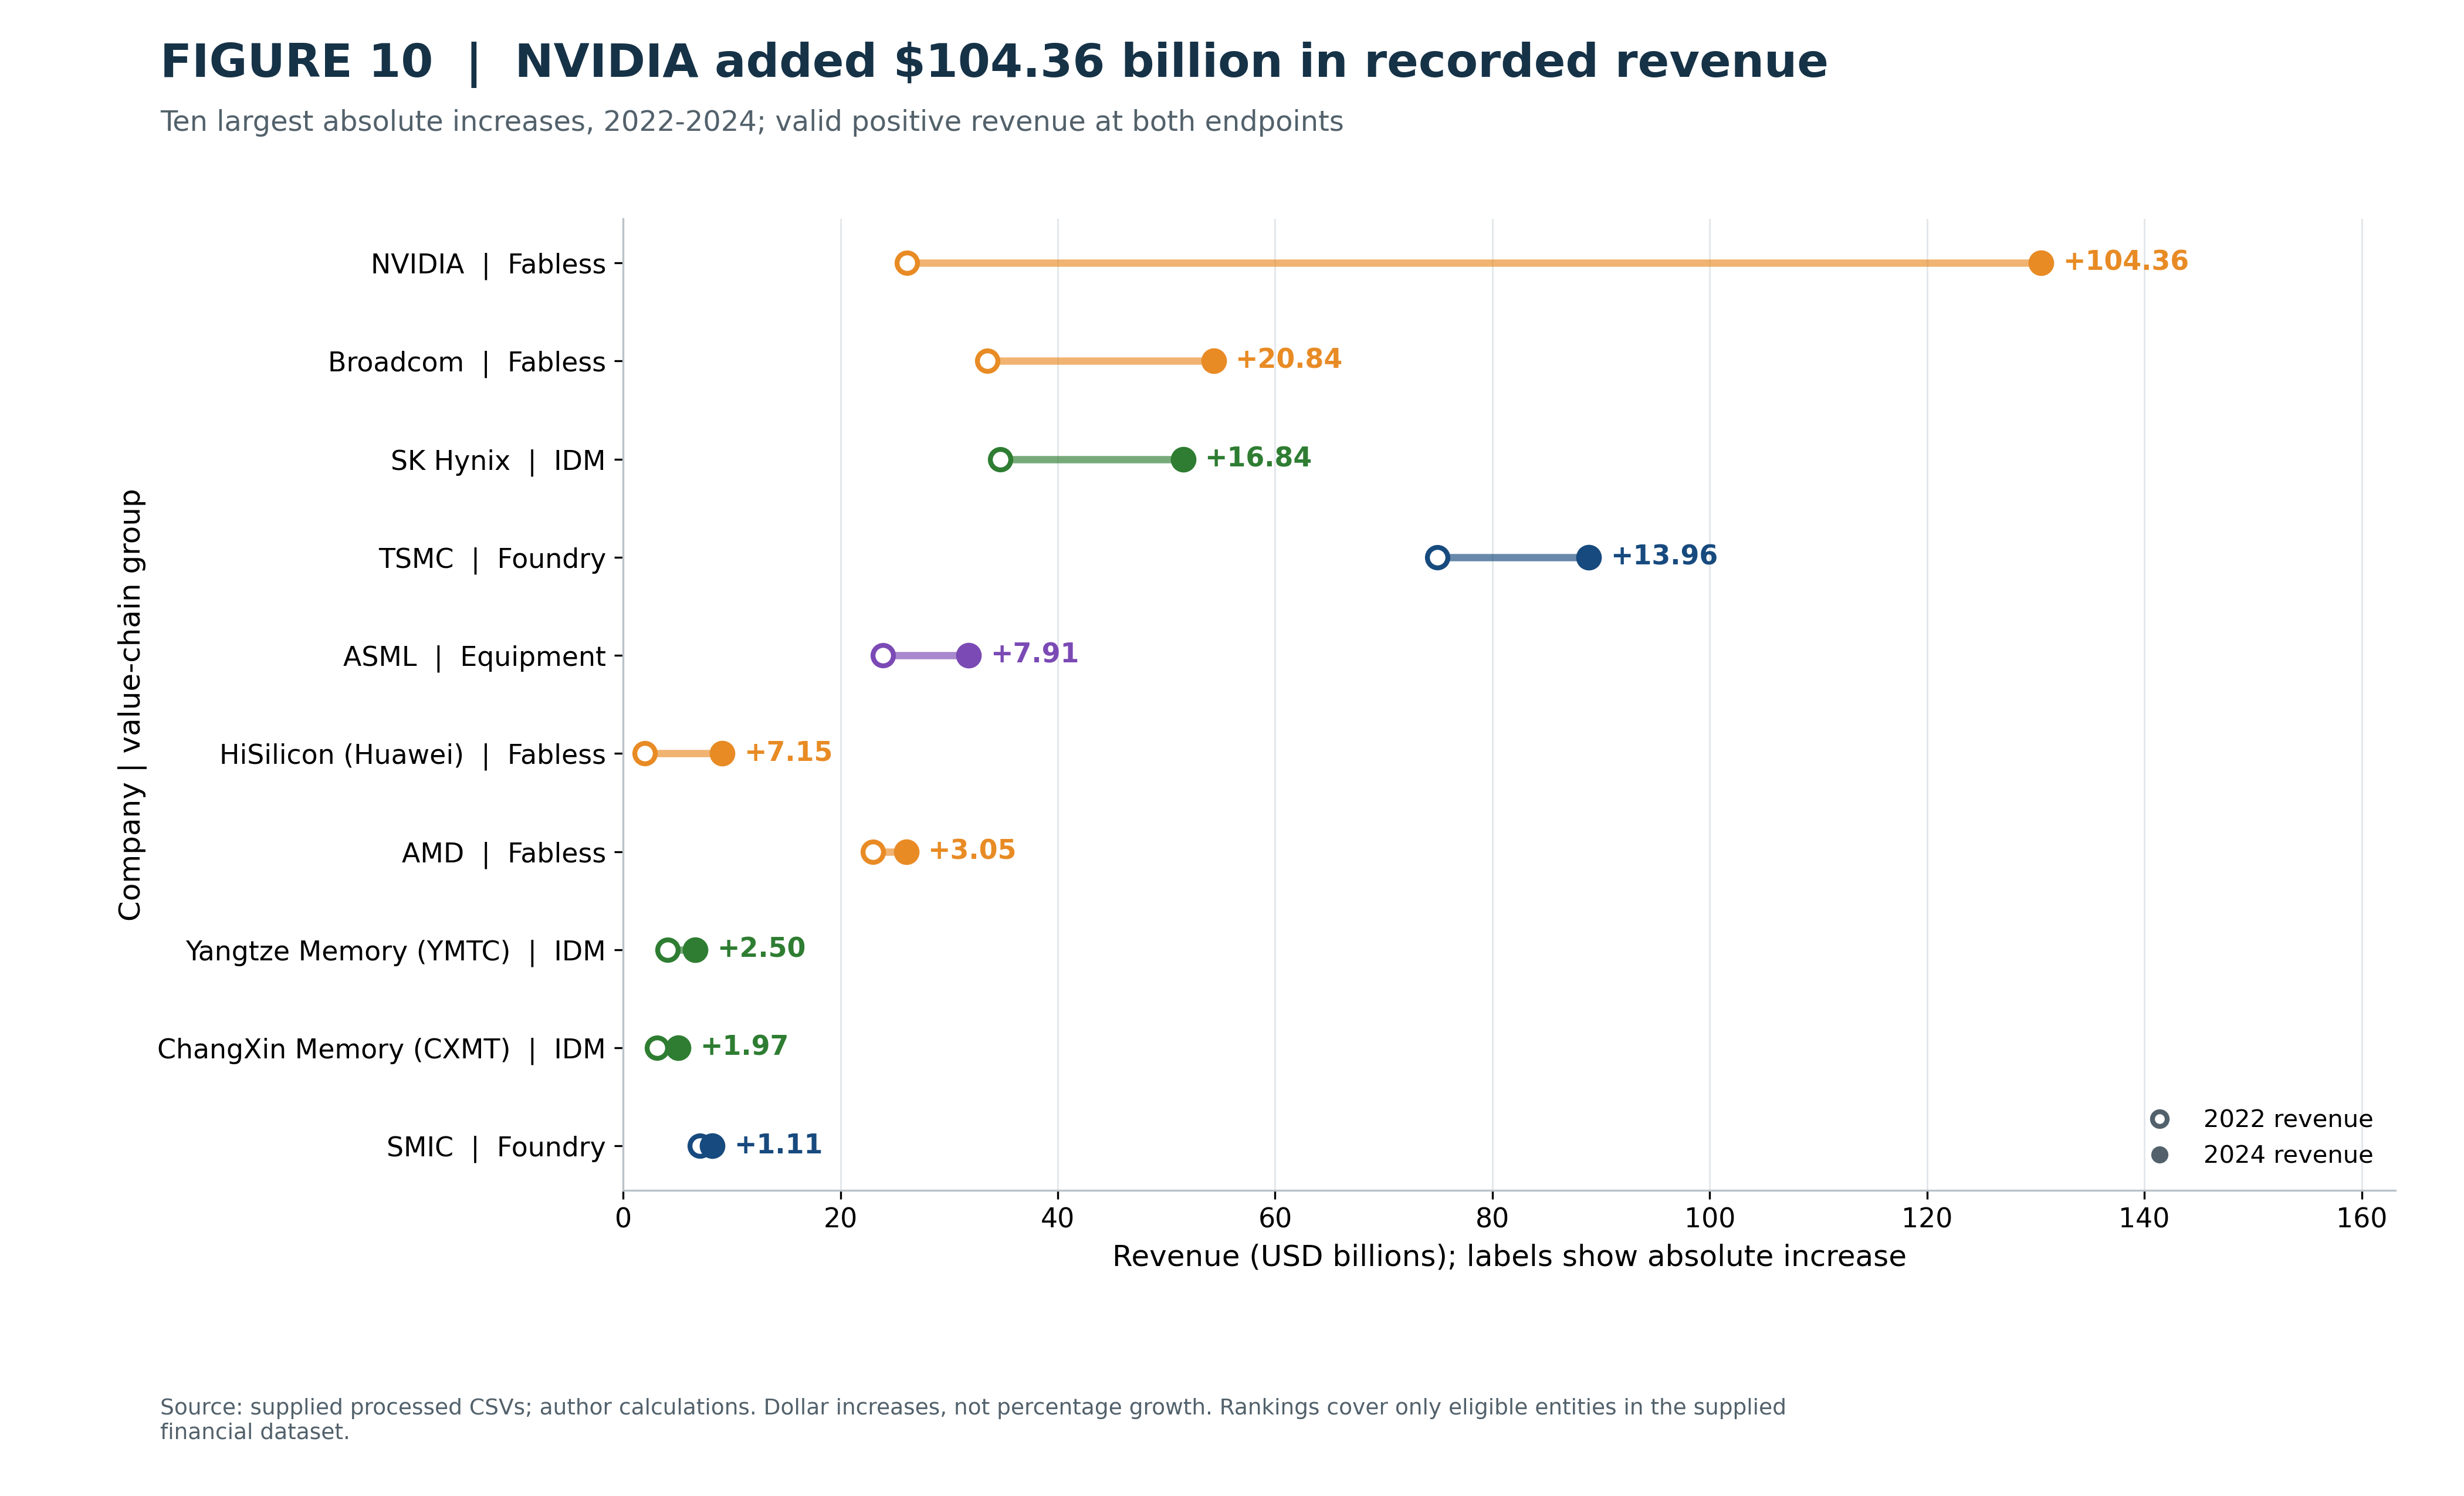

**Confirmed finding from the supplied data:** NVIDIA led absolute growth, rising from $26.12bn to $130.48bn.

**Important limitation:** Positive-endpoint eligibility and dataset coverage define this ranking; the chart does not establish causes.

**Possible action or decision use:** Separate absolute contribution from percentage-growth rankings in the project presentation.

In [7]:
fig,ax=plt.subplots(figsize=(14,8.5))
for y,(company,row) in enumerate(top_growth.iterrows()):
    color=COLORS[row.value_chain_group]
    ax.plot([row.revenue_2022,row.revenue_2024],[y,y],color=color,lw=3,alpha=.65)
    ax.scatter(row.revenue_2022,y,s=70,facecolor='white',edgecolor=color,lw=2,zorder=3)
    ax.scatter(row.revenue_2024,y,s=90,color=color,zorder=3)
    ax.text(row.revenue_2024+2,y,f'+{row.absolute_change_usd_bn:,.2f}',va='center',fontsize=11,fontweight='bold',color=color)
ax.set_yticks(range(len(top_growth)),[f'{c}  |  {r.value_chain_group}' for c,r in top_growth.iterrows()])
style(ax,'Revenue (USD billions); labels show absolute increase','Company | value-chain group',False)
ax.set_yticks(range(len(top_growth)),[f'{c}  |  {r.value_chain_group}' for c,r in top_growth.iterrows()])
assert [t.get_text() for t in ax.get_yticklabels()]==[f'{c}  |  {r.value_chain_group}' for c,r in top_growth.iterrows()]
ax.grid(axis='x',color='#E3E7EB',lw=.7); ax.set_xlim(0,top_growth.revenue_2024.max()*1.25)
ax.legend(handles=[Line2D([],[],marker='o',ls='',mfc='white',mec='#52616B',mew=2,label='2022 revenue'),Line2D([],[],marker='o',ls='',color='#52616B',label='2024 revenue')],frameon=False,loc='lower right')
leader=top_growth.iloc[-1]
save(fig,10,'company_absolute_growth',f'{top_growth.index[-1]} added ${leader.absolute_change_usd_bn:,.2f} billion in recorded revenue','Ten largest absolute increases, 2022-2024; valid positive revenue at both endpoints','Dollar increases, not percentage growth. Rankings cover only eligible entities in the supplied financial dataset.',2024)
interpretation(10,f'{top_growth.index[-1]} led absolute growth, rising from ${leader.revenue_2022:,.2f}bn to ${leader.revenue_2024:,.2f}bn.','A large company can drive aggregate dollar growth even when smaller firms grow faster in percentage terms.','Separate absolute contribution from percentage-growth rankings in the project presentation.','Positive-endpoint eligibility and dataset coverage define this ranking; the chart does not establish causes.')

## Figure 11 - Concentration and largest-company sensitivity
**Question:** How concentrated is dataset revenue, and how does removing the largest 2024 entity change the total and value-chain picture?
Annual shares use that year's dataset revenue denominator. The sensitivity table reports 2024 revenue in USD billions with and without the largest entity; it is a descriptive exclusion scenario, not a counterfactual forecast.

In [8]:
concentration=[]
for year,g in fin.groupby('year'):
    shares=(g.revenue_usd_bn/g.revenue_usd_bn.sum()*100).sort_values(ascending=False)
    assert abs(shares.sum()-100)<1e-9
    concentration.append({'year':year,'Largest company':shares.iloc[0],'Top three':shares.head(3).sum(),'Top five':shares.head(5).sum()})
concentration=pd.DataFrame(concentration)
f24=fin[fin.year.eq(2024)]
largest=f24.nlargest(1,'revenue_usd_bn').iloc[0]
without=f24[f24.company_name.ne(largest.company_name)]
full_group=f24.groupby('value_chain_group').revenue_usd_bn.sum().reindex(GROUPS)
without_group=without.groupby('value_chain_group').revenue_usd_bn.sum().reindex(GROUPS,fill_value=0)
sensitivity=pd.DataFrame({'All entities':full_group,'Without largest':without_group})
sensitivity.loc['TOTAL']=[f24.revenue_usd_bn.sum(),without.revenue_usd_bn.sum()]
chart_inputs[11]=concentration
display(concentration.round(2)); display(sensitivity.round(2))

,year,Largest company,Top three,Top five
0,2010,18.86,37.80,48.68
1,2011,18.28,37.91,48.80
2,2012,19.00,38.59,49.70
3,2013,17.87,38.15,50.56
4,2014,17.24,38.75,51.30
5,2015,16.92,38.18,52.55
6,2016,16.59,38.62,51.30
7,2017,15.38,37.68,50.84
8,2018,15.95,37.35,50.94
9,2019,15.00,38.07,49.78


,All entities,Without largest
value_chain_group,,
Foundry,131.07,131.07
Fabless,284.01,153.53
IDM,301.22,301.22
Equipment,101.83,101.83
EDA Software,10.38,10.38
TOTAL,828.51,698.03


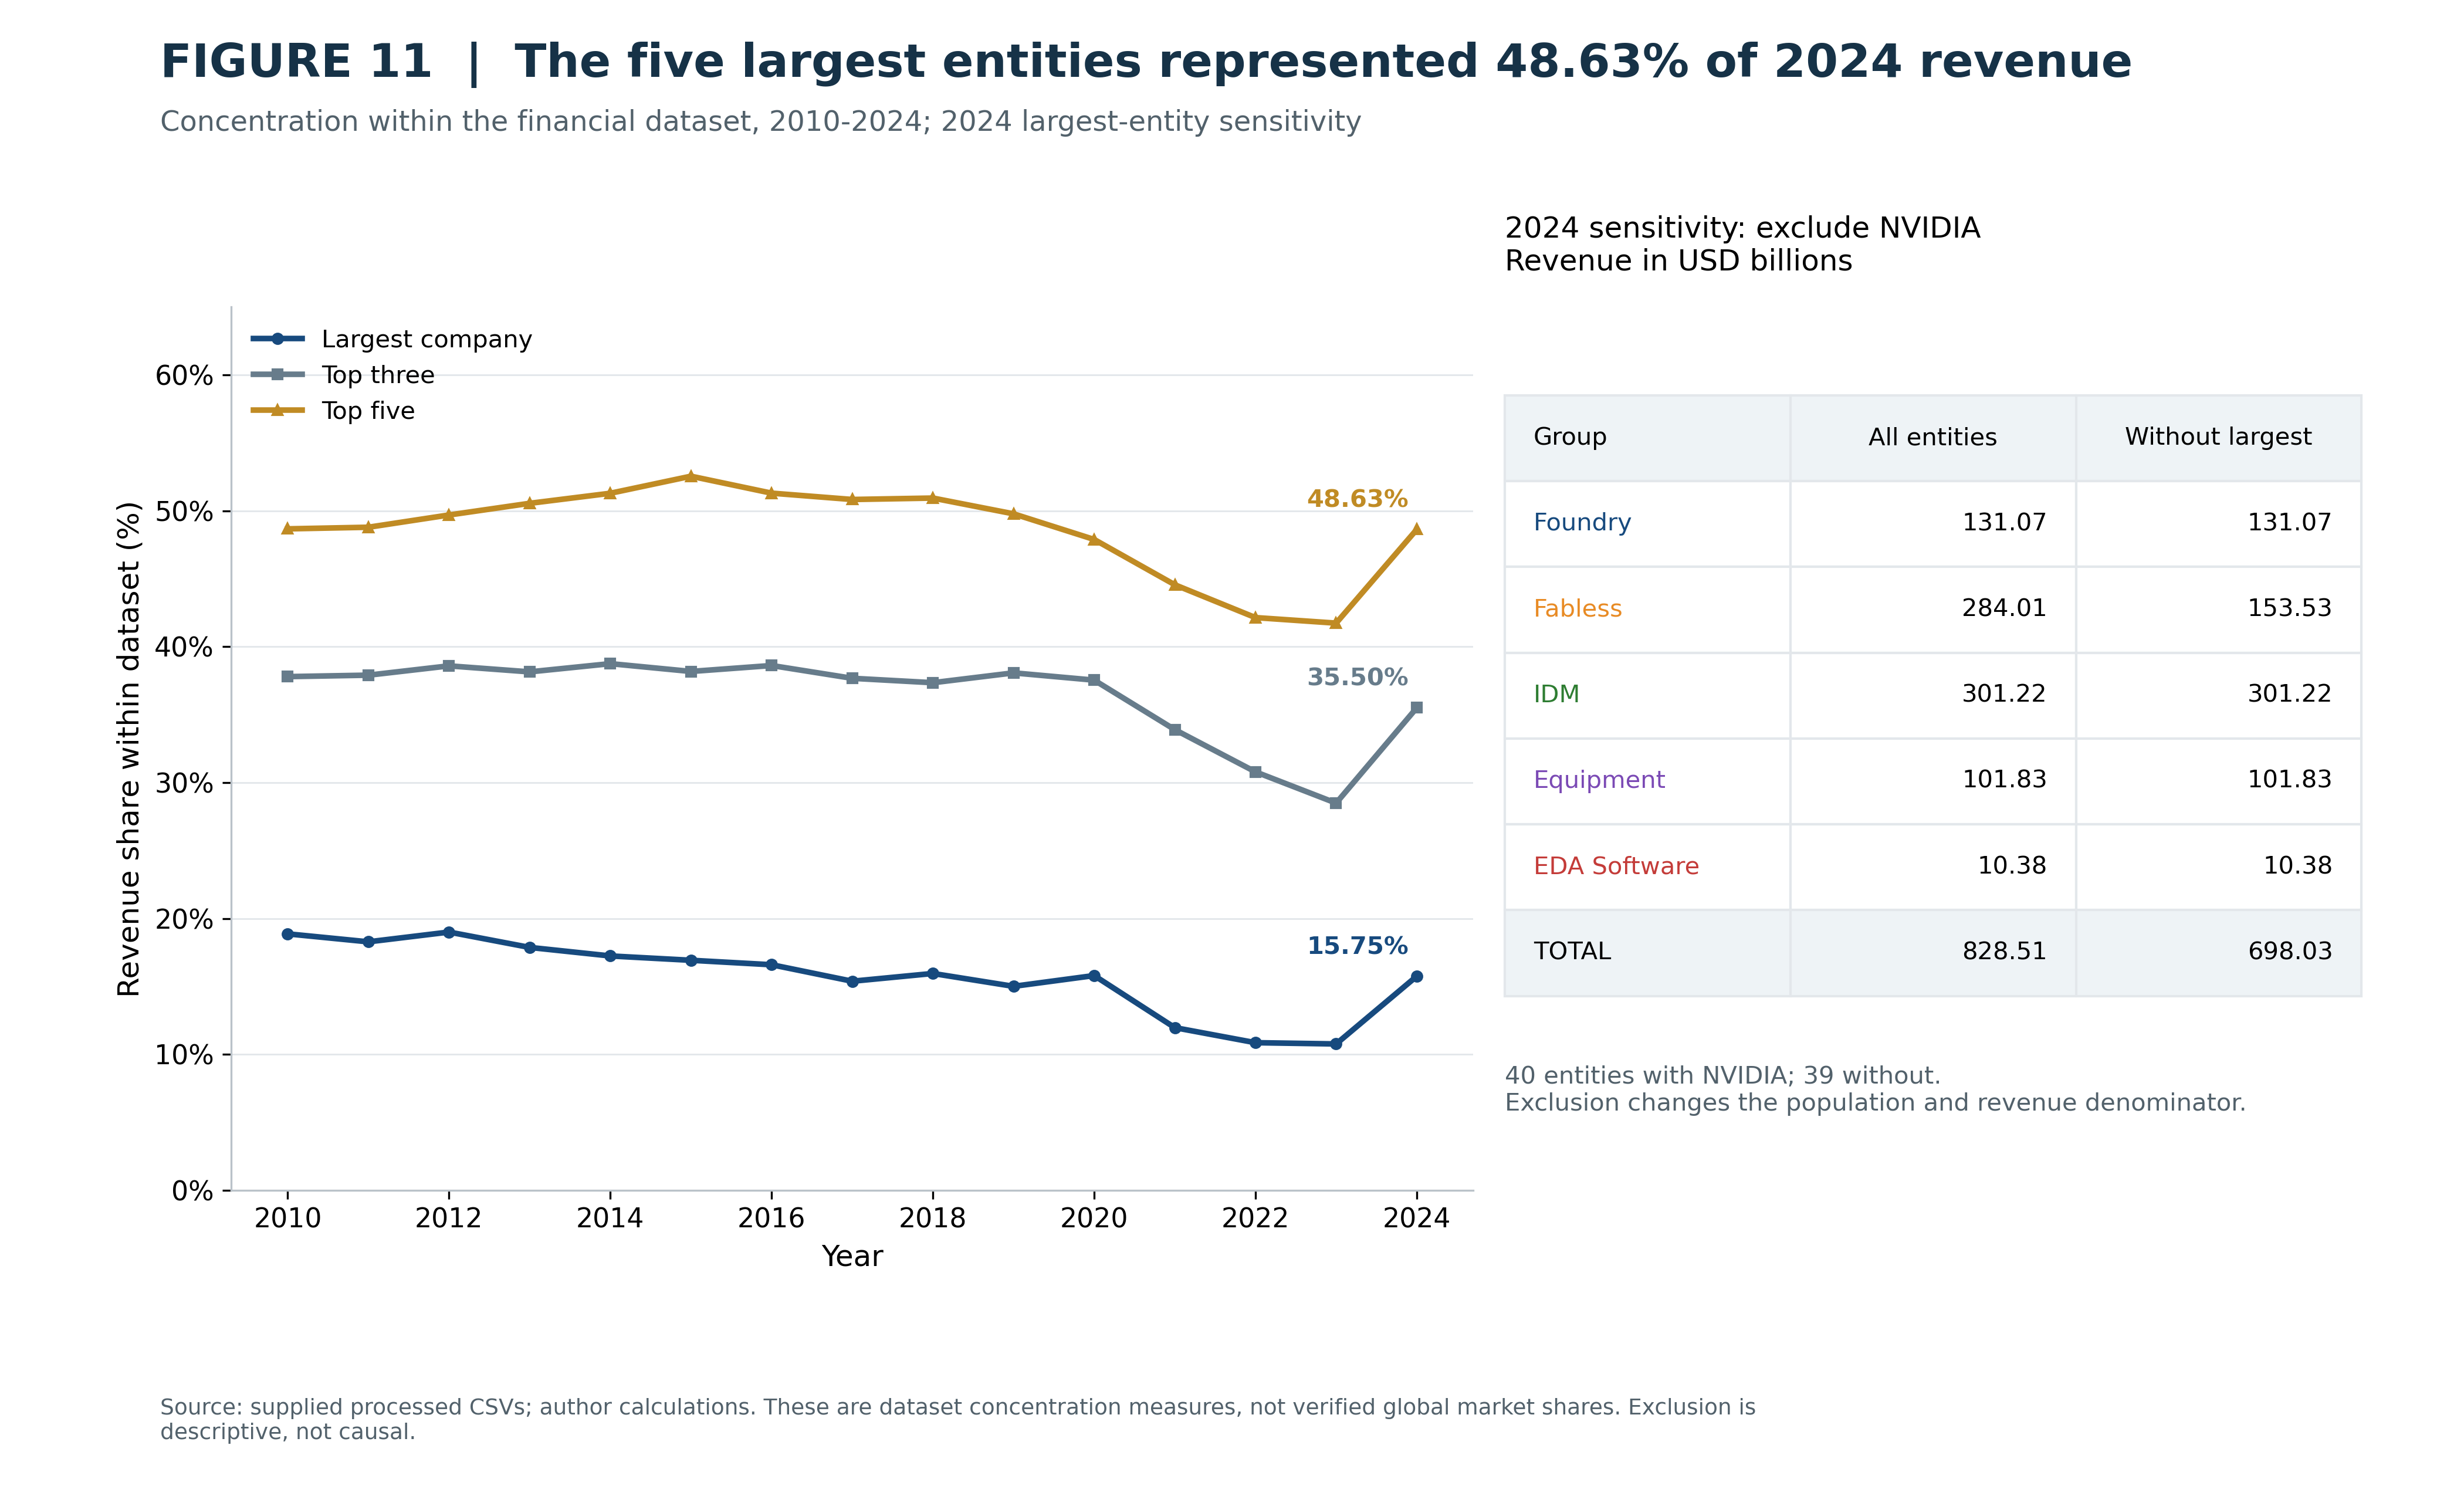

**Confirmed finding from the supplied data:** The top five represented 48.63% in 2024. Excluding NVIDIA reduces the total from $828.51bn to $698.03bn.

**Important limitation:** A 2024 exclusion alone does not quantify growth contributions across time or establish causation.

**Possible action or decision use:** Present aggregate and largest-company-excluded results together when discussing breadth of growth.

In [9]:
fig,(ax,tabax)=plt.subplots(1,2,figsize=(14,8.5),gridspec_kw={'width_ratios':[1.45,1]})
for column,color,marker in [('Largest company','#174A7E','o'),('Top three','#677C8B','s'),('Top five','#C08B24','^')]:
    ax.plot(concentration.year,concentration[column],label=column,color=color,marker=marker,lw=2.3,ms=4)
    ax.annotate(f'{concentration[column].iloc[-1]:.2f}%',(2024,concentration[column].iloc[-1]),xytext=(-45,9),textcoords='offset points',color=color,fontweight='bold',fontsize=10)
style(ax,'Year','Revenue share within dataset (%)'); ax.yaxis.set_major_formatter(PercentFormatter()); ax.set_ylim(0,65); ax.set_xticks(range(2010,2025,2)); ax.legend(frameon=False,loc='upper left')
tabax.axis('off'); tabax.set_title(f'2024 sensitivity: exclude {largest.company_name}\nRevenue in USD billions',loc='left',fontsize=12,pad=15)
rows=[[idx,f'{r["All entities"]:,.2f}',f'{r["Without largest"]:,.2f}'] for idx,r in sensitivity.iterrows()]
tab=tabax.table(cellText=rows,colLabels=['Group','All entities','Without largest'],cellLoc='right',loc='upper center',bbox=[0,.22,1,.68])
tab.auto_set_font_size(False); tab.set_fontsize(10)
for (r,c),cell in tab.get_celld().items():
    cell.set_edgecolor('#E3E7EB'); cell.set_facecolor('#EEF3F6' if r in [0,6] else 'white')
    if c==0:
        cell.set_text_props(ha='left')
        if 1<=r<=5: cell.get_text().set_color(COLORS[GROUPS[r-1]])
tabax.text(0,.09,f'{len(f24)} entities with {largest.company_name}; {len(without)} without.\nExclusion changes the population and revenue denominator.',transform=tabax.transAxes,fontsize=10,color='#52616B')
save(fig,11,'concentration_sensitivity','The five largest entities represented 48.63% of 2024 revenue','Concentration within the financial dataset, 2010-2024; 2024 largest-entity sensitivity','These are dataset concentration measures, not verified global market shares. Exclusion is descriptive, not causal.',2024)
interpretation(11,f'The top five represented {concentration["Top five"].iloc[-1]:.2f}% in 2024. Excluding {largest.company_name} reduces the total from ${f24.revenue_usd_bn.sum():,.2f}bn to ${without.revenue_usd_bn.sum():,.2f}bn.','Headline totals can be sensitive to a dominant entity.','Present aggregate and largest-company-excluded results together when discussing breadth of growth.','A 2024 exclusion alone does not quantify growth contributions across time or establish causation.')

## Figure 12 - Estimated AI-chip revenue and product coverage
**Question:** How did estimated vendor revenue and represented product coverage change during 2022-2024?
Vendor revenue is summed only across supplied chip records. NVIDIA's share uses the supplied AI-chip dataset denominator. Product counts are unique vendor-chip pairs per year.

In [10]:
ai_hist=ai[ai.year.between(2022,2024)].copy()
ai_vendor=ai_hist.groupby(['year','vendor'],as_index=False).estimated_revenue_usd_m.sum()
ai_totals=ai_hist.groupby('year').agg(estimated_revenue_usd_m=('estimated_revenue_usd_m','sum'),products=('chip_name','nunique'),vendors=('vendor','nunique'),zero_asp_rows=('zero_asp_flag','sum'))
assert ai_hist.groupby('year').apply(lambda g:g[['vendor','chip_name']].drop_duplicates().shape[0],include_groups=False).equals(ai_totals.products)
vendor_order=ai_vendor.groupby('vendor').estimated_revenue_usd_m.sum().sort_values(ascending=False).index.tolist()
vendor_wide=ai_vendor.pivot(index='year',columns='vendor',values='estimated_revenue_usd_m').reindex(columns=vendor_order).fillna(0)/1000
vendor_shares=vendor_wide.div(vendor_wide.sum(axis=1),axis=0)*100
assert vendor_shares.sum(axis=1).sub(100).abs().lt(1e-9).all()
chart_inputs[12]=ai_totals.reset_index()
display(ai_totals.round(2)); display(vendor_wide.round(3))

,estimated_revenue_usd_m,products,vendors,zero_asp_rows
year,,,,
2022,2283.0,8,6,0
2023,23611.1,15,7,1
2024,109819.4,26,11,2


vendor,NVIDIA,Google,AMD,Huawei,AWS,Cerebras,Groq,SambaNova,Cambricon,Apple,Tenstorrent
year,,,,,,,,,,,
2022,2.227,0.020,0.015,0.005,0.000,0.00,0.000,0.000,0.016,0.000,0.000
2023,19.454,0.914,0.011,0.478,2.738,0.00,0.000,0.004,0.013,0.000,0.000
2024,83.457,11.431,7.518,4.982,1.672,0.57,0.131,0.050,0.006,0.003,0.001


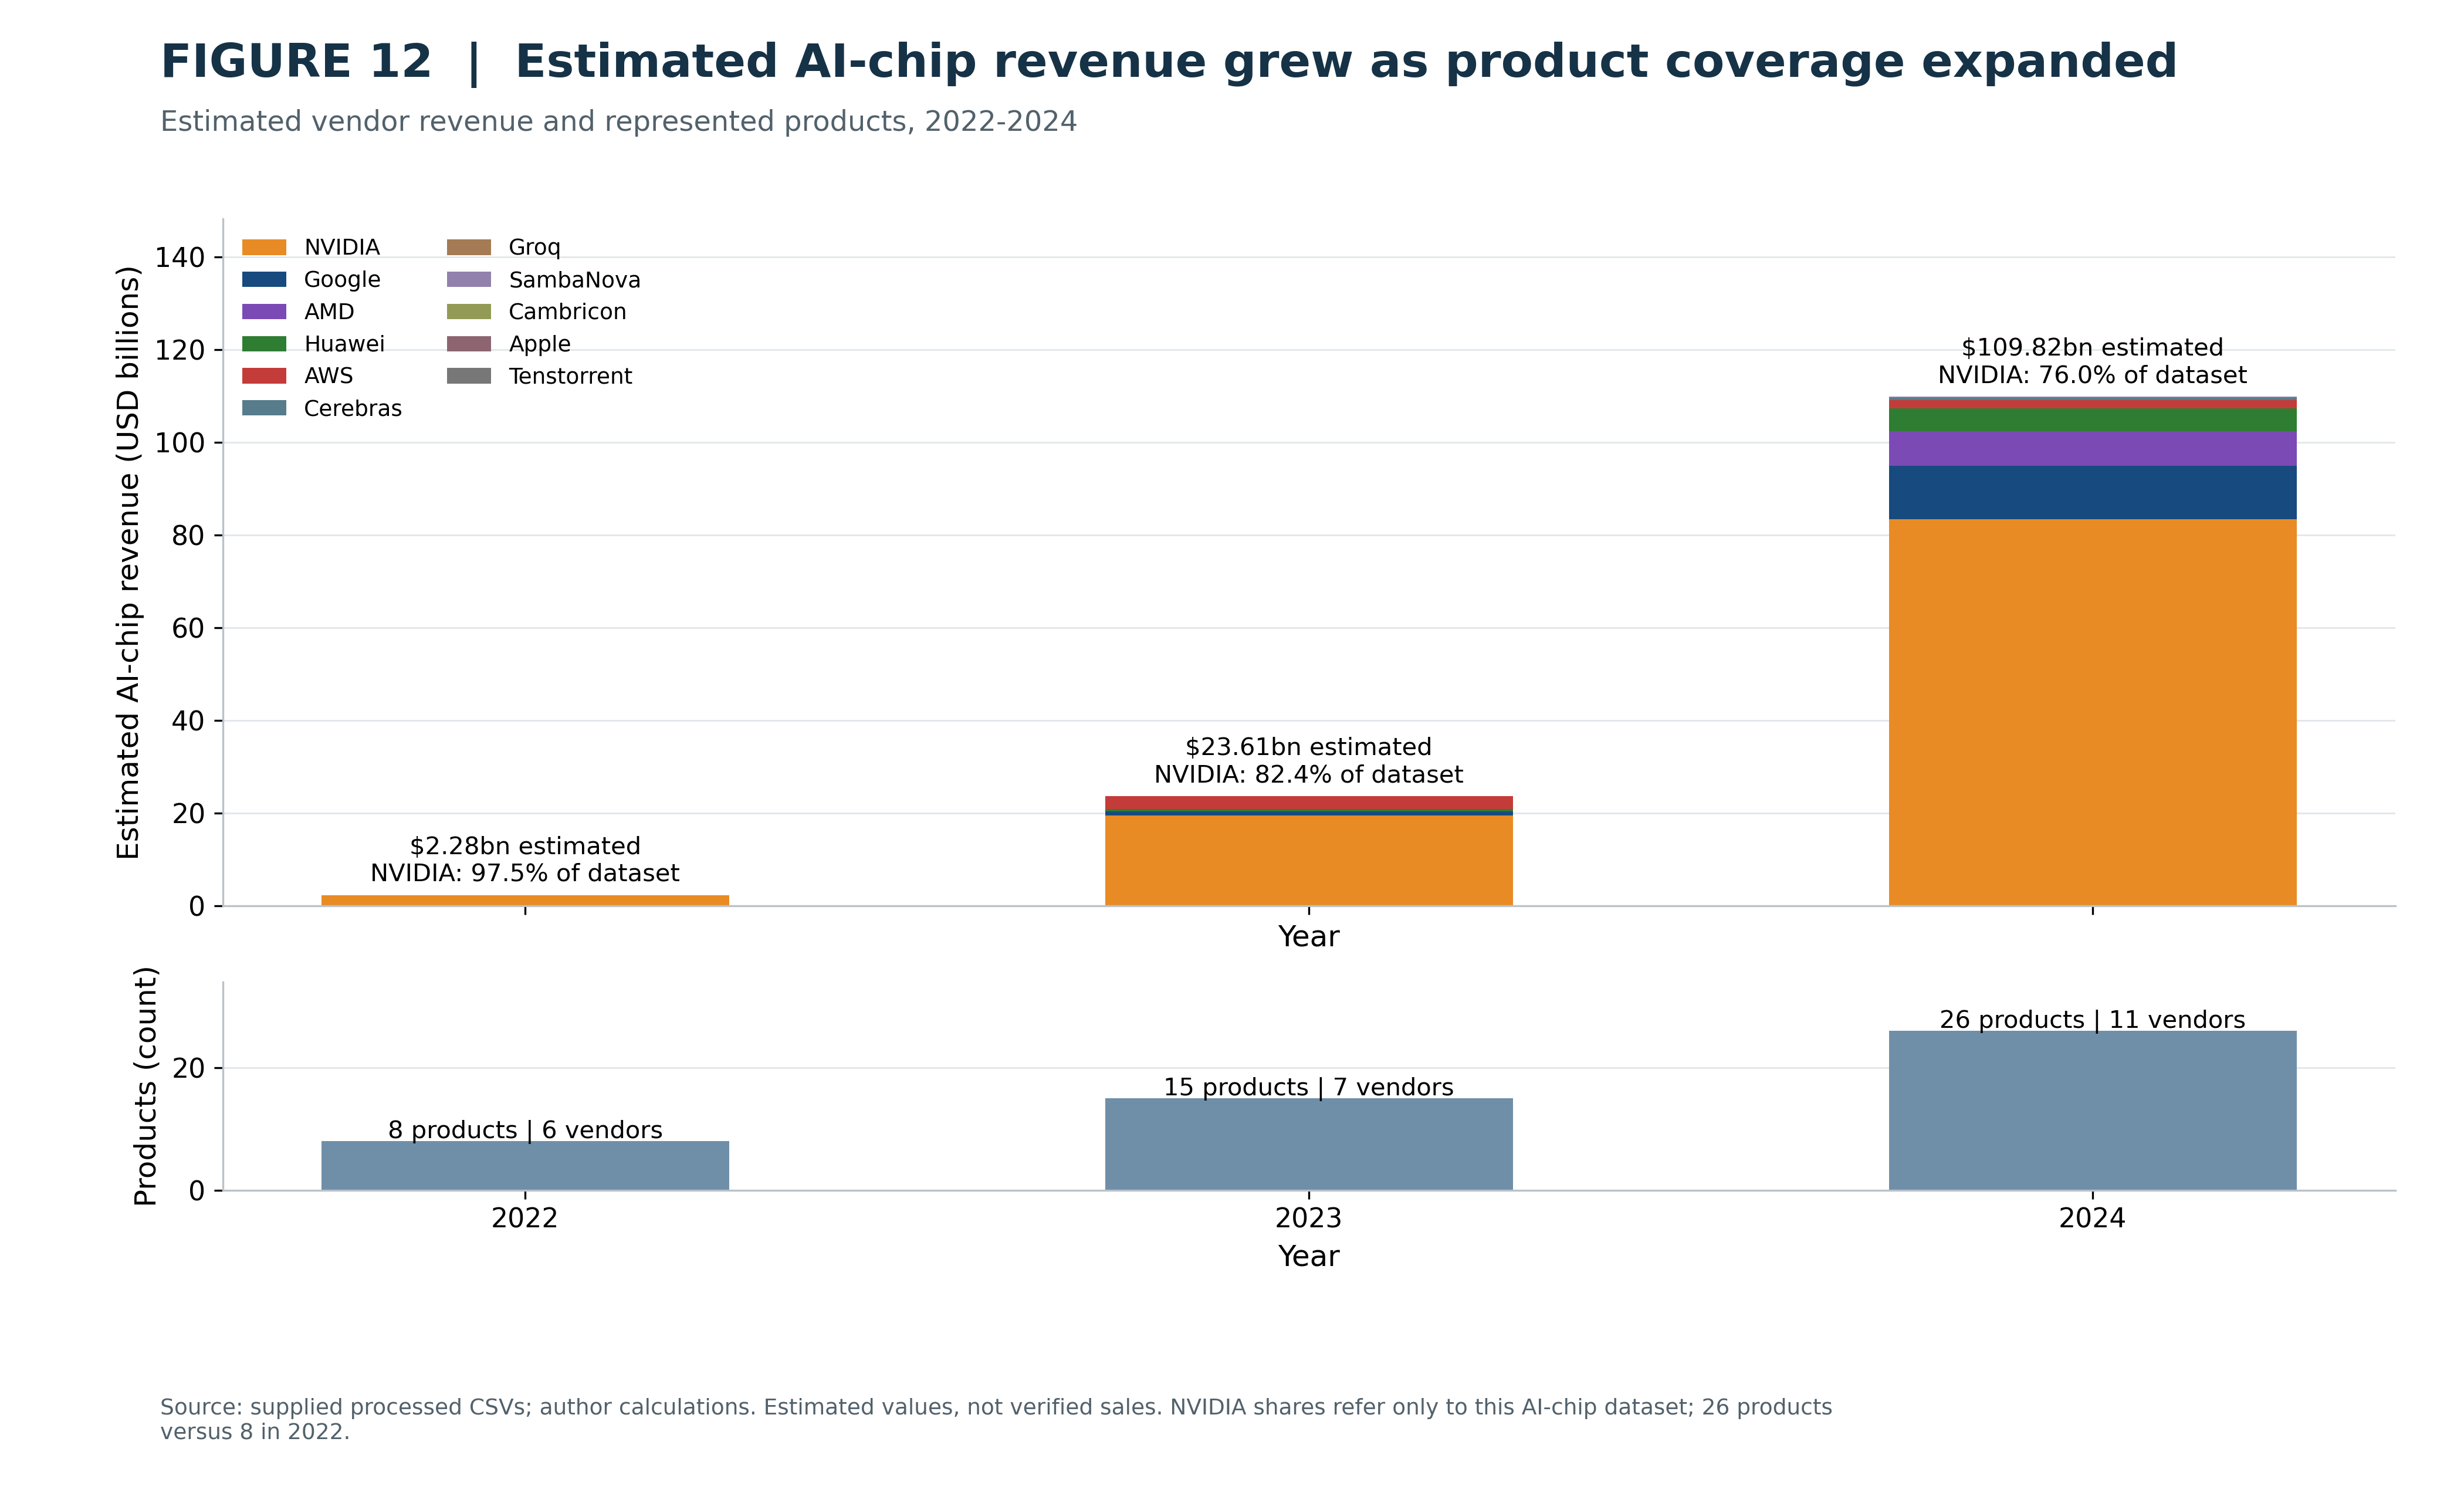

**Confirmed finding from the supplied data:** Estimated revenue rose from $2.28bn to $109.82bn; products increased from 8 to 26. NVIDIA represented 76.0% of 2024 estimated dataset revenue.

**Important limitation:** AI revenue is estimated, zero-price records remain, and coverage changes. Do not interpret these as verified global market shares.

**Possible action or decision use:** Validate estimates and compare a fixed-product cohort before making demand projections.

In [11]:
fig,(ax,bottom)=plt.subplots(2,1,figsize=(14,8.5),sharex=True,gridspec_kw={'height_ratios':[3.3,1]})
palette=['#E88B25','#174A7E','#7B4AB5','#2E7D32','#C43C39','#577C8C','#A47B54','#9181AC','#929A56','#8C6571','#777777']
base=pd.Series(0.,index=vendor_wide.index)
for vendor,color in zip(vendor_order,palette):
    ax.bar(vendor_wide.index,vendor_wide[vendor],bottom=base,label=vendor,color=color,width=.52); base+=vendor_wide[vendor]
for year,total in base.items():
    ax.text(year,total+3,f'${total:,.2f}bn estimated\nNVIDIA: {vendor_shares.loc[year,"NVIDIA"]:.1f}% of dataset',ha='center',fontsize=10)
ax.set_ylim(0,base.max()*1.35); ax.legend(frameon=False,ncol=2,loc='upper left',fontsize=9)
bottom.bar(ai_totals.index,ai_totals.products,color='#6F8FA9',width=.52)
for year,row in ai_totals.iterrows(): bottom.text(year,row.products+.5,f'{int(row.products)} products | {int(row.vendors)} vendors',ha='center',fontsize=10)
bottom.set_ylim(0,34); bottom.set_xticks([2022,2023,2024])
style(ax,'Year','Estimated AI-chip revenue (USD billions)'); style(bottom,'Year','Products (count)')
save(fig,12,'estimated_ai_revenue_coverage','Estimated AI-chip revenue grew as product coverage expanded','Estimated vendor revenue and represented products, 2022-2024','Estimated values, not verified sales. NVIDIA shares refer only to this AI-chip dataset; 26 products versus 8 in 2022.',2024)
interpretation(12,f'Estimated revenue rose from ${ai_totals.loc[2022,"estimated_revenue_usd_m"]/1000:.2f}bn to ${ai_totals.loc[2024,"estimated_revenue_usd_m"]/1000:.2f}bn; products increased from 8 to 26. NVIDIA represented {vendor_shares.loc[2024,"NVIDIA"]:.1f}% of 2024 estimated dataset revenue.','Estimated growth reflects a widening observed product set as well as changes in estimates.','Validate estimates and compare a fixed-product cohort before making demand projections.','AI revenue is estimated, zero-price records remain, and coverage changes. Do not interpret these as verified global market shares.')

## Figure 13 - Semiconductor price index (explicit source-review exception)
**Question:** Did the five products follow a common price cycle over the same observed window?
Use October 2024-April 2026 exactly, October 2024 = 100 for each product. This specifically requested chart includes source-review years and is excluded from historical financial conclusions. Normalization does not make different product units interchangeable.

In [12]:
products=['HBM3_stack','NAND_64Gb_MLC','DRAM_DDR4_8Gb','NVIDIA_B200','NVIDIA_H100']
price_window=prices[prices['product'].isin(products)&prices.month_date.between('2024-10-01','2026-04-01')].copy()
assert price_window.groupby('product').month_date.nunique().eq(19).all()
assert price_window.groupby('product').unit.nunique().eq(1).all()
assert price_window.currency.eq('USD').all()
base_prices=price_window[price_window.month_date.eq('2024-10-01')].set_index('product').price
assert base_prices.index.is_unique and base_prices.gt(0).all()
price_window['index']=price_window.price/price_window['product'].map(base_prices)*100
index_wide=price_window.pivot(index='month_date',columns='product',values='index').reindex(columns=products)
price_summary=pd.DataFrame({'base_price_original_unit':base_prices,'last_price_original_unit':price_window[price_window.month_date.eq('2026-04-01')].set_index('product').price,'unit':price_window.groupby('product').unit.first(),'final_index':index_wide.iloc[-1],'change_pct':index_wide.iloc[-1]-100,'months':19}).reindex(products)
chart_inputs[13]=index_wide
display(price_summary.round(2))

,base_price_original_unit,last_price_original_unit,unit,final_index,change_pct,months
product,,,,,,
HBM3_stack,686.42,840.99,USD/stack,122.52,22.52,19
NAND_64Gb_MLC,4.05,4.25,USD/chip,104.94,4.94,19
DRAM_DDR4_8Gb,2.10,2.19,USD/chip,104.29,4.29,19
NVIDIA_B200,42124.09,30295.89,USD/unit,71.92,-28.08,19
NVIDIA_H100,29365.39,19321.24,USD/unit,65.80,-34.20,19


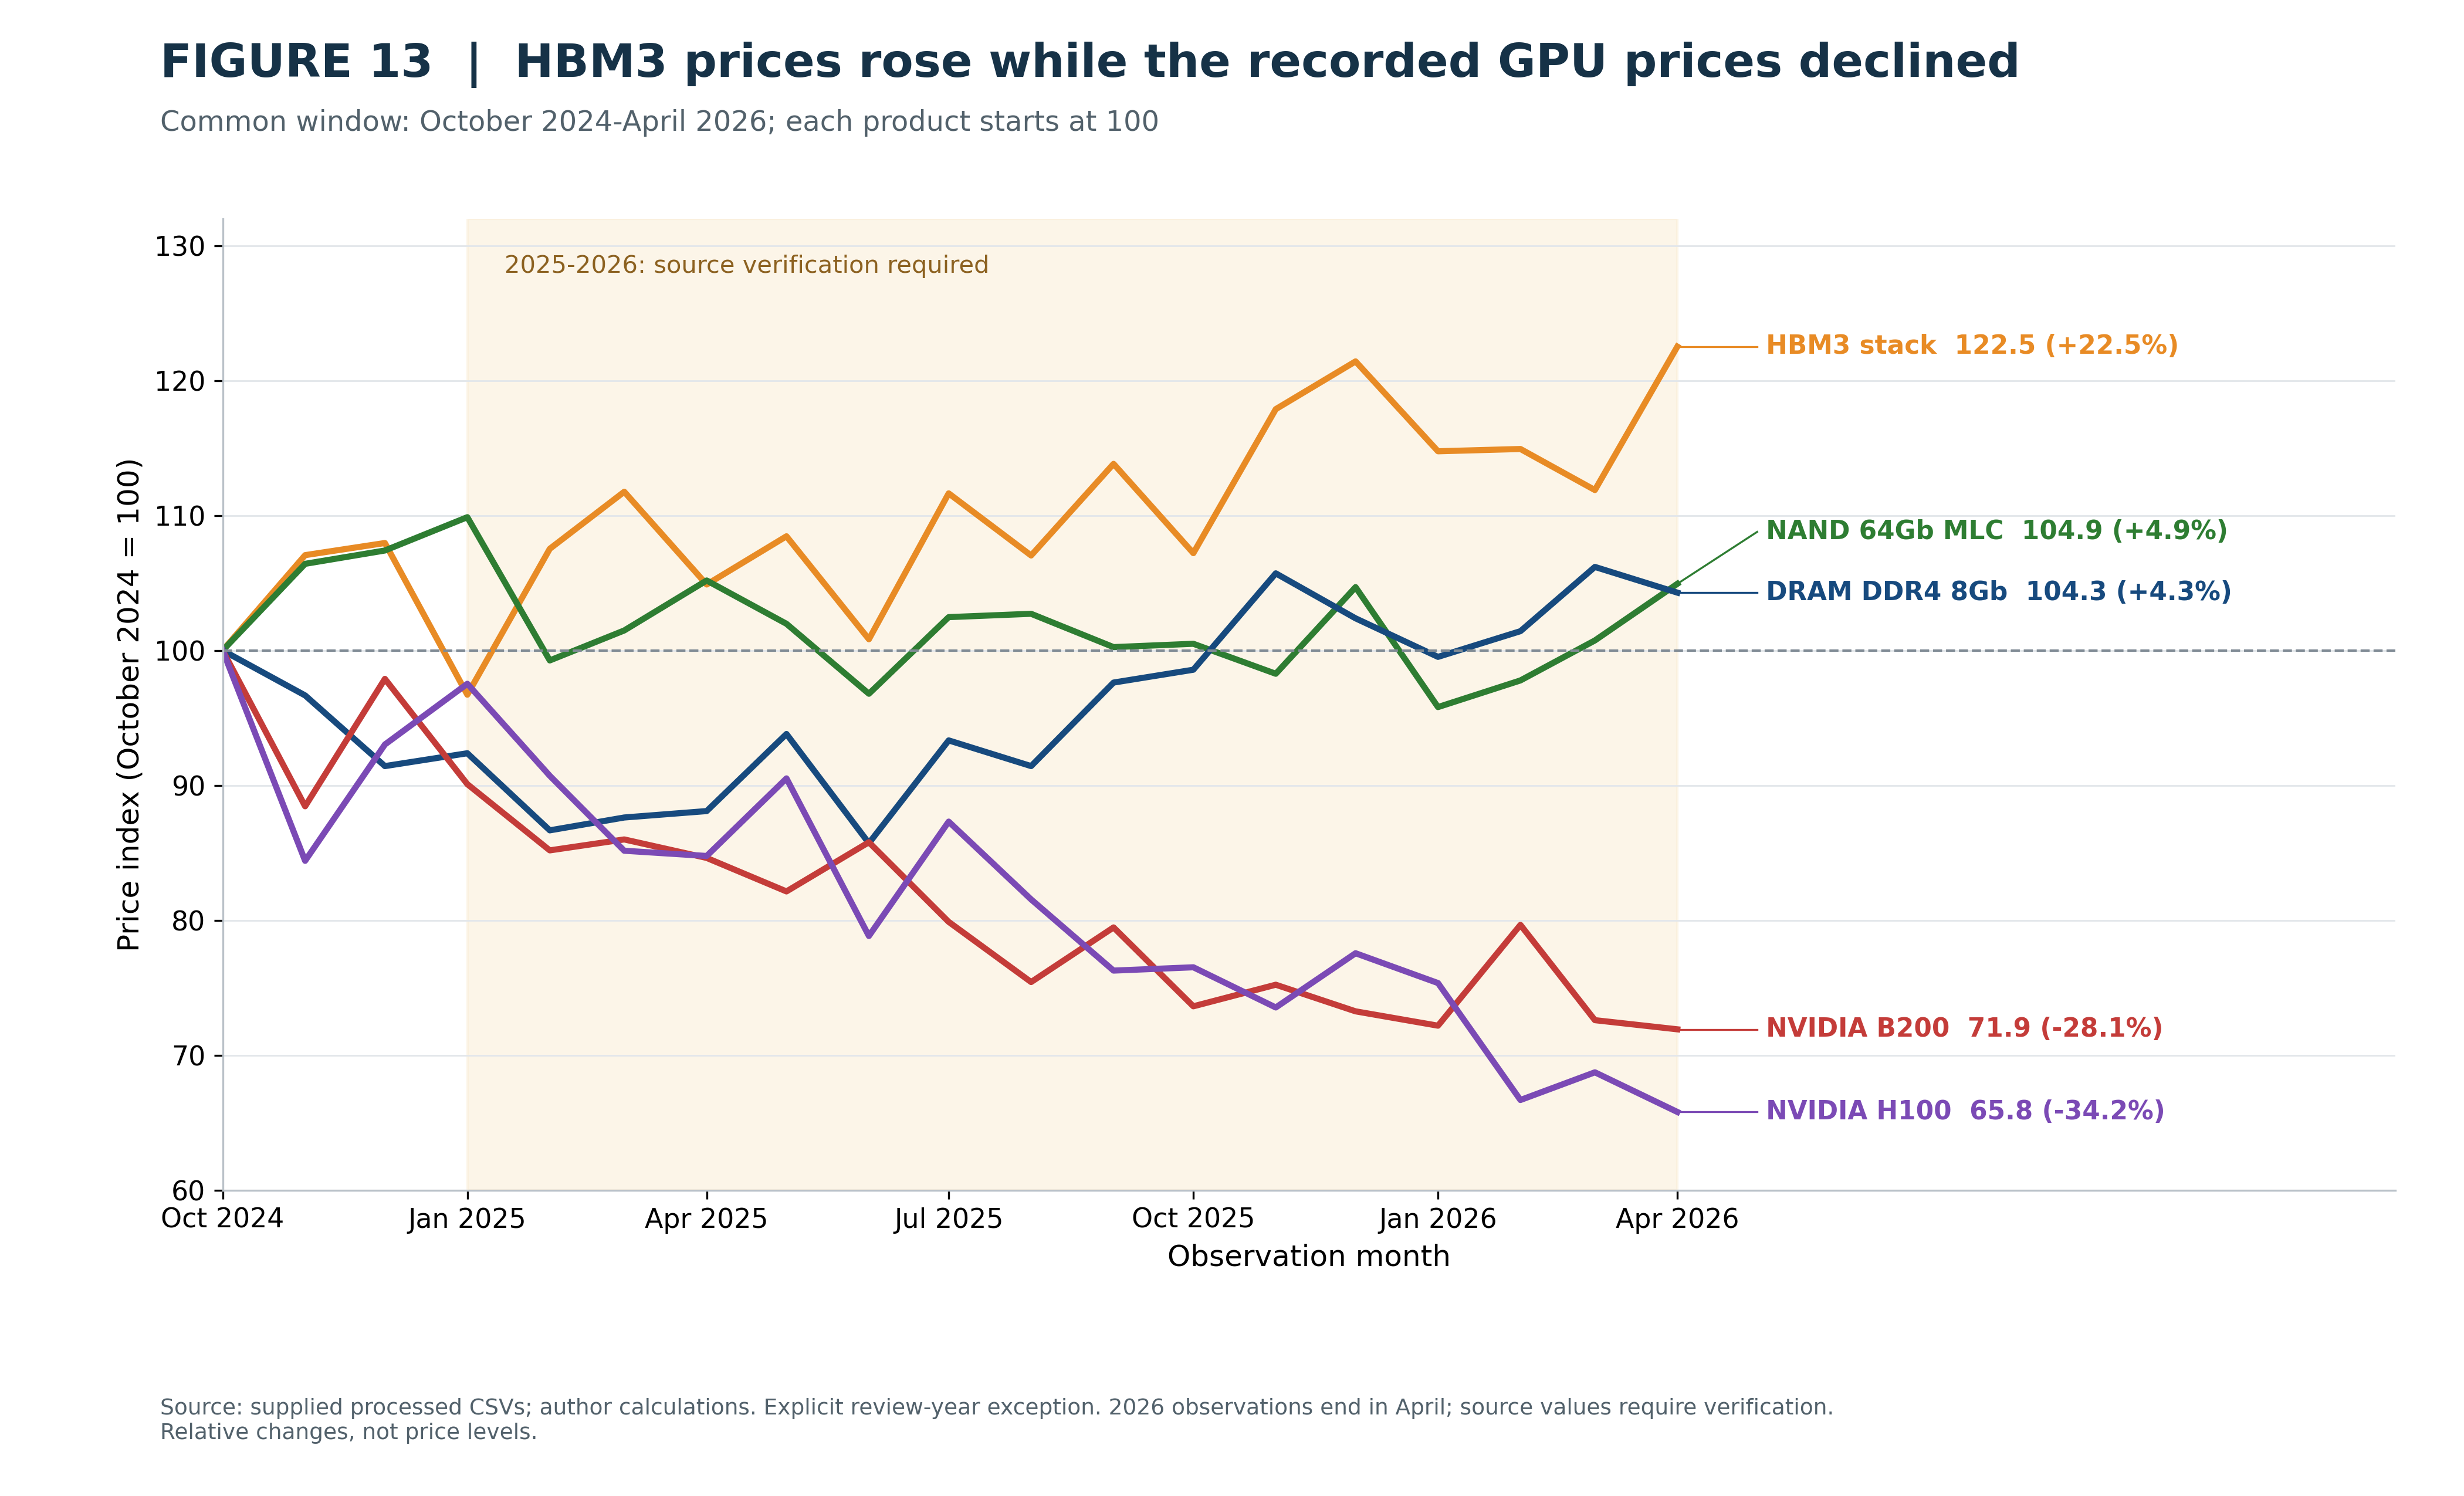

**Confirmed finding from the supplied data:** HBM3 increased 22.5%; H100 and B200 changed -34.2% and -28.1%, respectively.

**Important limitation:** 2025-2026 are unverified source-review years; 2026 is partial, and product specifications and price bases differ.

**Possible action or decision use:** Track product-specific price indexes and verify later-year source values before using them for planning.

In [13]:
fig,ax=plt.subplots(figsize=(14,8.5))
names={'HBM3_stack':'HBM3 stack','NAND_64Gb_MLC':'NAND 64Gb MLC','DRAM_DDR4_8Gb':'DRAM DDR4 8Gb','NVIDIA_B200':'NVIDIA B200','NVIDIA_H100':'NVIDIA H100'}
price_colors=dict(zip(products,['#E88B25','#2E7D32','#174A7E','#C43C39','#7B4AB5']))
end=index_wide.index[-1]; label_date=end+pd.Timedelta(days=30)
label_positions={}; last=-float('inf')
for product,value in index_wide.iloc[-1].sort_values().items():
    label_positions[product]=max(value,last+4.5); last=label_positions[product]
for product in products:
    ax.plot(index_wide.index,index_wide[product],color=price_colors[product],lw=2.5)
    value=index_wide[product].iloc[-1]; label_y=label_positions[product]
    ax.plot([end,label_date],[value,label_y],color=price_colors[product],lw=.8)
    ax.text(label_date,label_y,f' {names[product]}  {value:.1f} ({value-100:+.1f}%)',va='center',fontsize=10.5,color=price_colors[product],fontweight='bold')
ax.axhline(100,color='#808B95',lw=1,ls='--')
ax.axvspan(pd.Timestamp('2025-01-01'),end,color='#FAEDD6',alpha=.55,zorder=0)
ax.text(pd.Timestamp('2025-01-15'),128,'2025-2026: source verification required',fontsize=10,color='#8C6120')
ax.set_xlim(index_wide.index[0],end+pd.Timedelta(days=270)); ax.set_ylim(60,132)
ax.set_xticks(pd.date_range('2024-10-01','2026-04-01',freq='3MS')); ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
style(ax,'Observation month','Price index (October 2024 = 100)')
save(fig,13,'product_price_index','HBM3 prices rose while the recorded GPU prices declined','Common window: October 2024-April 2026; each product starts at 100','Explicit review-year exception. 2026 observations end in April; source values require verification. Relative changes, not price levels.',2026)
interpretation(13,f'HBM3 increased {price_summary.loc["HBM3_stack","change_pct"]:.1f}%; H100 and B200 changed {price_summary.loc["NVIDIA_H100","change_pct"]:.1f}% and {price_summary.loc["NVIDIA_B200","change_pct"]:.1f}%, respectively.','Product price cycles differ; a single semiconductor price trend can conceal opposing movements.','Track product-specific price indexes and verify later-year source values before using them for planning.','2025-2026 are unverified source-review years; 2026 is partial, and product specifications and price bases differ.')

## Figure 14 - Manufacturing capacity and policy context
**Question:** What reported capacity changes and recorded policy activity surround the 2022-2024 financial comparison?
Capacity values are sums of supplied records within categories. Mature logic includes `logic_mature` and `logic_mature_300mm`; packaging is excluded. Wafer equivalence and completeness are unverified. Event counts use unique control IDs, without severity weighting.

In [14]:
category_map={'logic_leading':'Leading-edge logic','logic_mature':'Mature logic','logic_mature_300mm':'Mature logic','memory_DRAM':'DRAM','memory_NAND':'NAND'}
cap=capacity[capacity.year.isin([2022,2024])&capacity.fab_type.isin(category_map)].copy()
cap['category']=cap.fab_type.map(category_map)
cap_summary=cap.groupby(['category','year'],as_index=False).agg(reported_monthly_capacity=('monthly_wafer_capacity','sum'),records=('company','size'),companies=('company','nunique'))
cap_order=['Leading-edge logic','Mature logic','DRAM','NAND']
cap_wide=cap_summary.pivot(index='category',columns='year',values='reported_monthly_capacity').reindex(cap_order)/1000
count_wide=cap_summary.pivot(index='category',columns='year',values='records').reindex(cap_order)
ev=events[events.year.between(2022,2024)]
event_counts=ev.groupby('year').control_id.nunique().reindex([2022,2023,2024],fill_value=0)
chart_inputs[14]=cap_summary
display(cap_summary); display(event_counts.rename('recorded_events').to_frame())

,category,year,reported_monthly_capacity,records,companies
0,DRAM,2022,1887500,5,4
1,DRAM,2024,1950226,6,4
2,Leading-edge logic,2022,459095,7,3
3,Leading-edge logic,2024,709925,12,4
4,Mature logic,2022,1372585,18,11
5,Mature logic,2024,1433053,19,11
6,NAND,2022,138619,1,1
7,NAND,2024,208976,1,1


,recorded_events
year,
2022,4
2023,7
2024,6


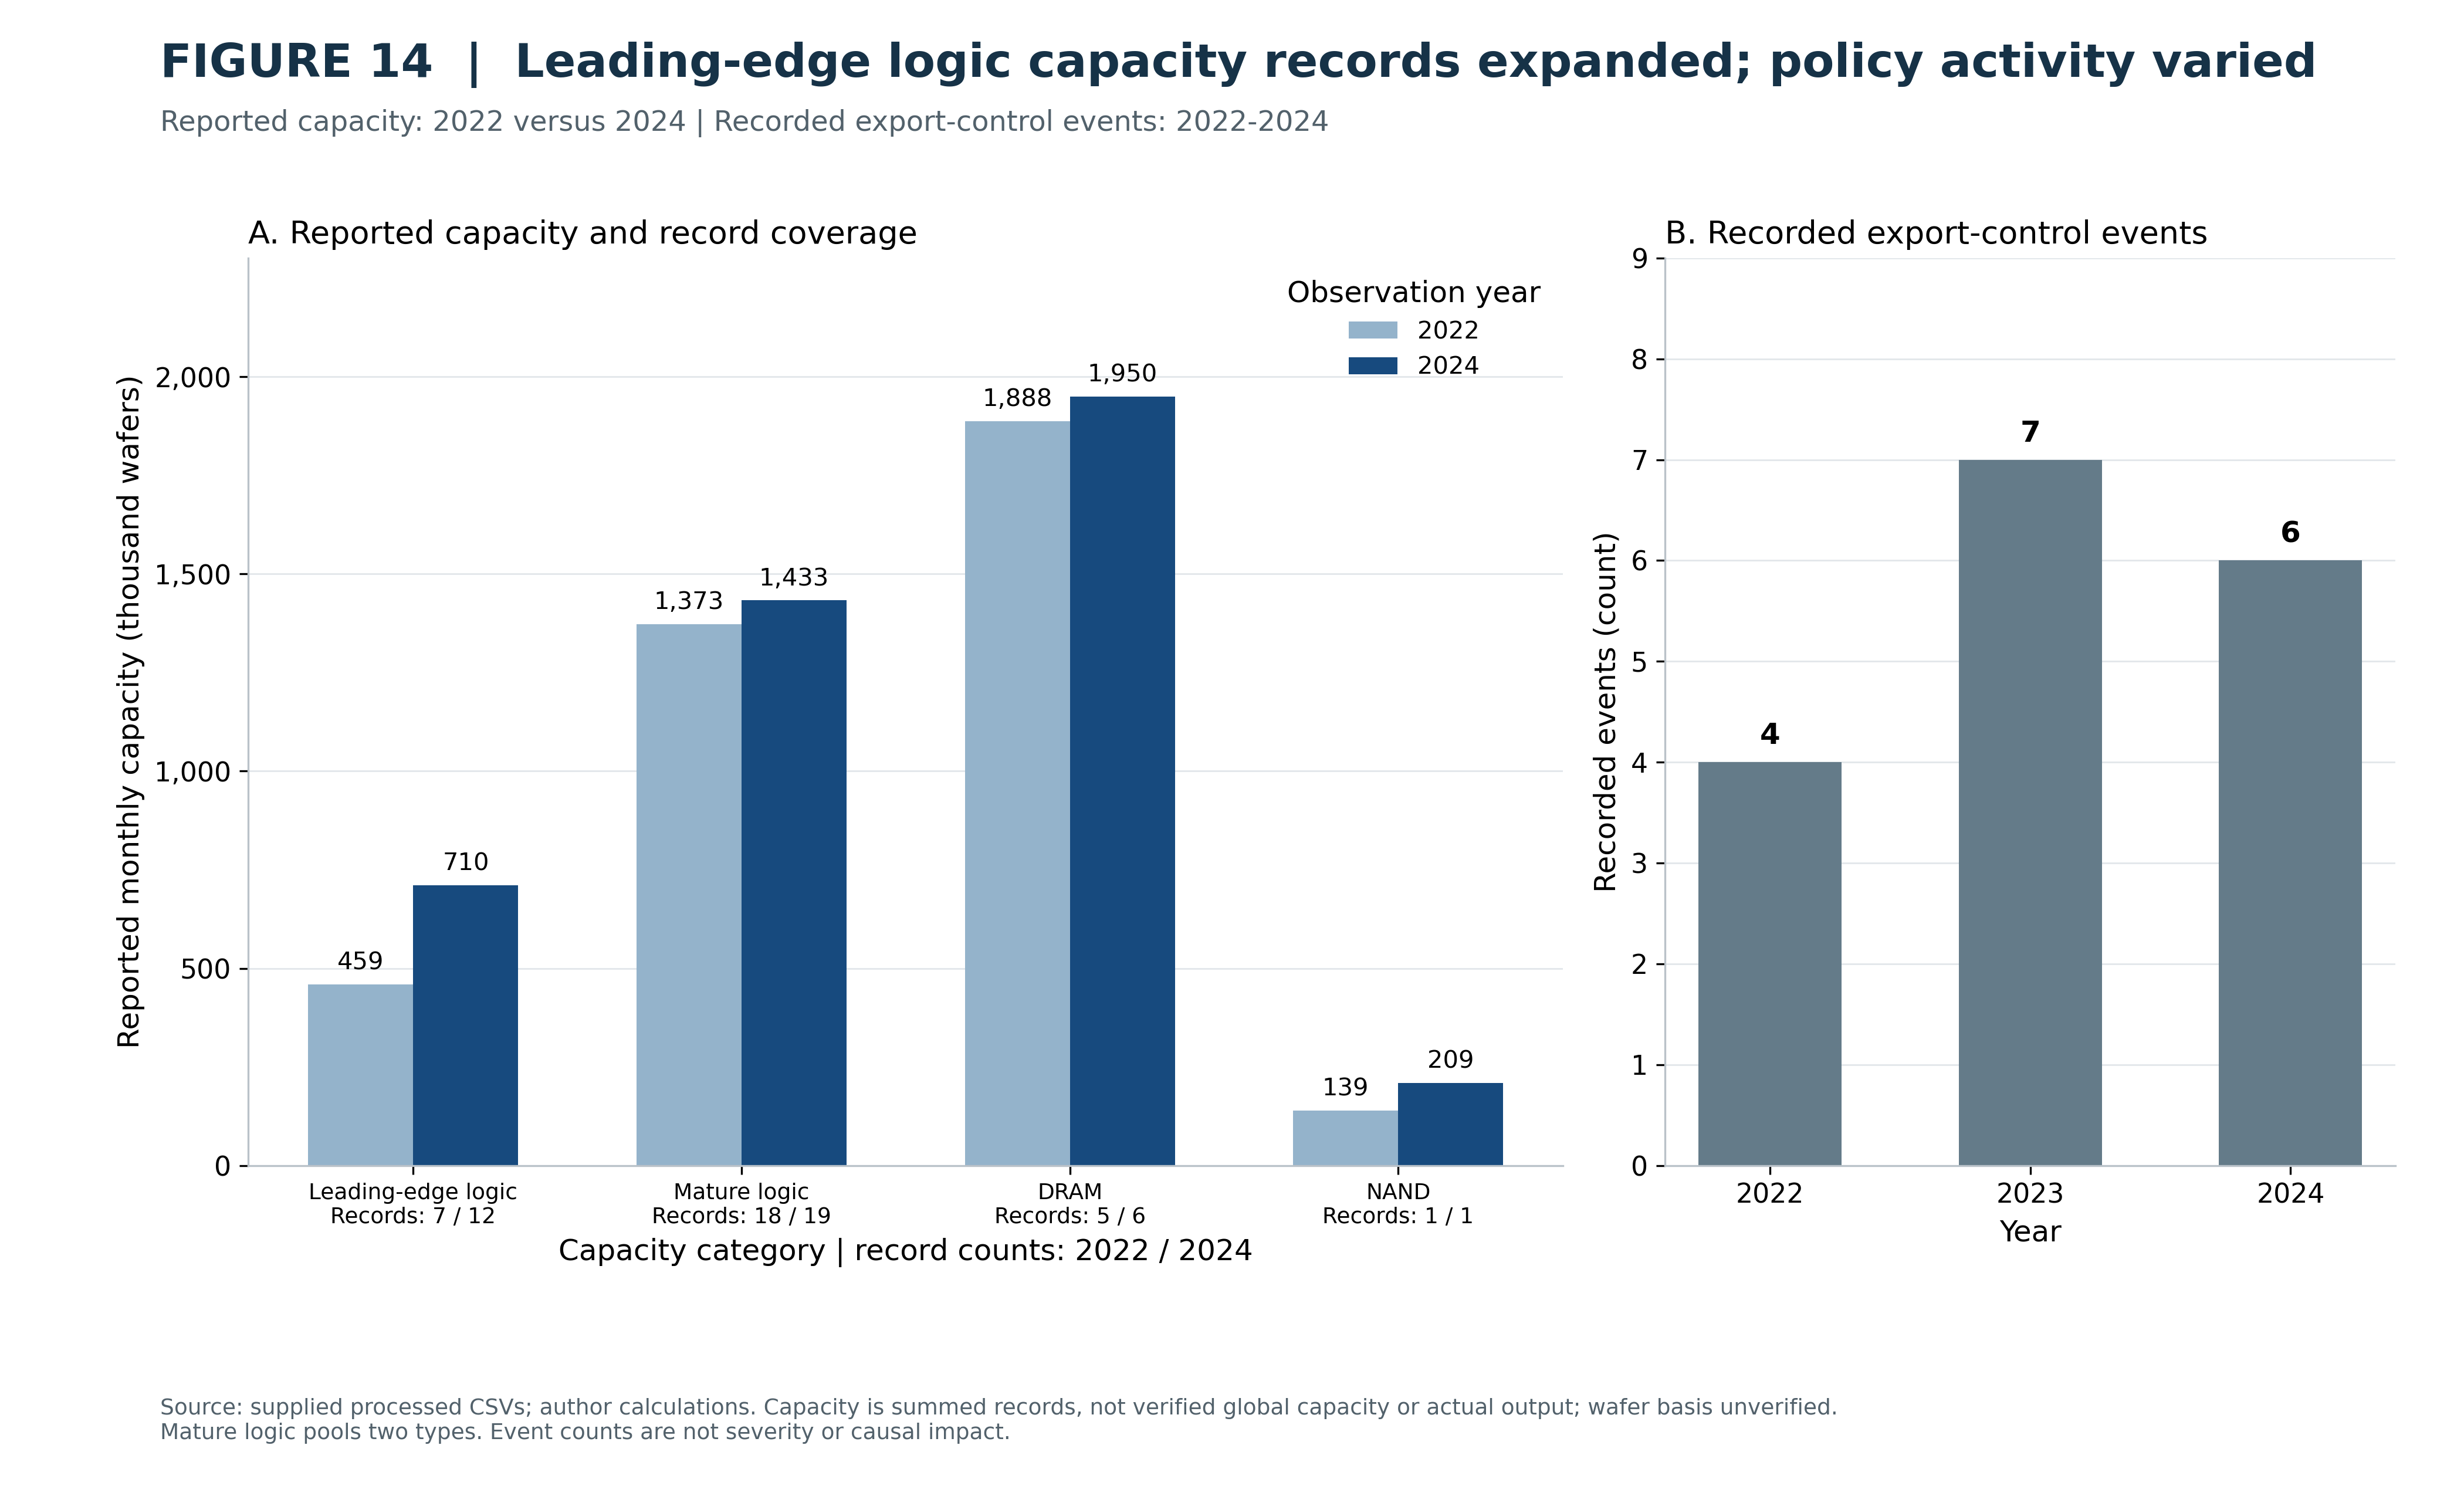

**Confirmed finding from the supplied data:** Leading-edge logic records sum to 459.1k in 2022 and 709.9k wafers/month in 2024. Recorded events number 4, 7 and 6 in 2022-2024.

**Important limitation:** Capacity record coverage changes and wafer equivalence is unverified. Counts are neither policy severity nor causal estimates.

**Possible action or decision use:** Validate capacity additions, wafer definitions and event details before drawing supply or policy-impact conclusions.

In [15]:
fig,(ax,policy)=plt.subplots(1,2,figsize=(14,8.5),gridspec_kw={'width_ratios':[1.8,1]})
x=list(range(4)); width=.32
for offset,year,color in [(-width/2,2022,'#94B3CB'),(width/2,2024,'#174A7E')]:
    bars=ax.bar([v+offset for v in x],cap_wide[year],width,color=color,label=str(year))
    ax.bar_label(bars,labels=[f'{v:,.0f}' for v in cap_wide[year]],padding=4,fontsize=10)
ax.set_xticks(x,[f'{c}\nRecords: {count_wide.loc[c,2022]} / {count_wide.loc[c,2024]}' for c in cap_order]); ax.tick_params(axis='x',labelsize=9)
ax.set_ylim(0,cap_wide.max().max()*1.18); ax.legend(frameon=False,title='Observation year')
ax.set_title('A. Reported capacity and record coverage',loc='left')
style(ax,'Capacity category | record counts: 2022 / 2024','Reported monthly capacity (thousand wafers)')
bars=policy.bar(event_counts.index,event_counts.values,color='#647B89',width=.55)
policy.bar_label(bars,padding=5,fontsize=12,fontweight='bold'); policy.set_ylim(0,9); policy.set_xticks(event_counts.index)
policy.set_title('B. Recorded export-control events',loc='left')
style(policy,'Year','Recorded events (count)')
save(fig,14,'capacity_policy_context','Leading-edge logic capacity records expanded; policy activity varied','Reported capacity: 2022 versus 2024 | Recorded export-control events: 2022-2024','Capacity is summed records, not verified global capacity or actual output; wafer basis unverified. Mature logic pools two types. Event counts are not severity or causal impact.',2024)
interpretation(14,f'Leading-edge logic records sum to {cap_wide.loc["Leading-edge logic",2022]:,.1f}k in 2022 and {cap_wide.loc["Leading-edge logic",2024]:,.1f}k wafers/month in 2024. Recorded events number 4, 7 and 6 in 2022-2024.','Capacity and policy provide distinct context for financial results.','Validate capacity additions, wafer definitions and event details before drawing supply or policy-impact conclusions.','Capacity record coverage changes and wafer equivalence is unverified. Counts are neither policy severity nor causal estimates.')

## Action-oriented summary and validation
Actions below are analytical and operational follow-ups, not investment recommendations. The source-review price figure is kept separate from historical financial conclusions.

In [16]:
summary=pd.DataFrame(findings)
display(summary)
summary.to_csv(OUT/'figure_findings.csv',index=False)
for number,table in chart_inputs.items(): table.to_csv(OUT/f'figure_{number:02d}_inputs.csv',index=True)
sensitivity.to_csv(OUT/'figure_11_sensitivity.csv')
price_summary.to_csv(OUT/'figure_13_price_summary.csv')
event_counts.to_csv(OUT/'figure_14_event_counts.csv')
output_table=pd.DataFrame(records)
assert len(output_table)==14
assert output_table.groupby('format').size().to_dict()=={'pdf':7,'png':7}
assert output_table.loc[output_table.figure.ne(13),'maximum_year'].le(2024).all()
assert output_table.loc[output_table.figure.eq(13),'maximum_year'].eq(2026).all()
assert fin.year.max()==2024
for table in chart_inputs.values():
    assert not table.select_dtypes('number').isin([float('inf'),float('-inf')]).any().any()
assert not sensitivity.isin([float('inf'),float('-inf')]).any().any()
for path,expected in before_hashes.items(): assert hashlib.sha256((ROOT/path).read_bytes()).hexdigest()==expected, path
for record in records:
    path=ROOT/record['file']; assert path.is_file() and path.stat().st_size>0
    record['bytes']=path.stat().st_size
    if record['format']=='png':
        with PILImage.open(path) as im:
            assert im.convert('RGBA').getchannel('A').getextrema()==(255,255)
            assert all(v>=299 for v in im.info['dpi'])
            assert im.convert('RGB').getpixel((0,0))==(255,255,255)
    else:
        assert path.read_bytes().startswith(b'%PDF')
output_table=pd.DataFrame(records)
output_table.to_csv(OUT/'saved_outputs.csv',index=False)
validation={'seven_pngs':True,'seven_pdfs':True,'png_background_opaque_white':True,'png_dpi_at_least_300':True,'pdf_export_white_background':True,'financial_years_through_2024':True,'figure_13_explicit_review_exception':True,'protected_sources_unchanged':True,'unique_company_year_keys':True,'validated_join_cardinality':True,'yearly_revenue_shares_sum_100':True,'no_infinite_chart_inputs':True,'all_titles_axes_and_notes_present':True}
(OUT/'validation.json').write_text(json.dumps(validation,indent=2),encoding='utf-8')
display(pd.Series(validation,name='passed').to_frame())
display(output_table[['figure','file','format','maximum_year','bytes']])
report=['# Final visualization conclusions','', 'Project: From Automotive AI to Generative AI: The Changing Semiconductor Value Chain.', '', 'Seven additional figures numbered 8-14. Each is saved in PNG (300 DPI) and PDF in figures/final/. Figure 13 is the explicitly requested October 2024-April 2026 source-review exception; financial conclusions end in 2024.', '', '| Figure | Main finding | Business implication | Possible action | Limitation |','|---|---|---|---|---|']
for row in findings: report.append('| '+' | '.join(str(row[c]).replace('|','/') for c in summary.columns)+' |')
report += ['', '## Findings supported by supplied data','', 'Revenue, entity/product coverage, rankings, concentration, prices, reported capacity and event counts are calculated from the supplied data. Computation checks passed; these are not independent factual verification.', '', '## Associations that do not establish causation','', 'Analytical period labels, contemporaneous policy events, and capacity movements do not prove automotive AI or Generative AI caused financial changes. The largest-company exclusion is a descriptive sensitivity check.', '', '## Values requiring independent verification','', 'AI-chip revenue is estimated. Figure 13 includes source-review years 2025-2026 and partial-year 2026 prices. Capacity totals are sums of reported records; wafer equivalence and global coverage are unverified. Policy counts are not severity scores.', '', '## Library use','', 'Pandas: reading processed CSVs, filtering, groupby/aggregation, pivoting, validated joins, shares, ranking, coverage, and tables. Matplotlib: all seven plots, subplots, annotations, tables, legends, date/number formatting, and high-resolution PNG/PDF export. No Seaborn, NumPy or Plotly is used in this notebook, following the supplied instructions.', '', '## Validation','', 'Seven PNGs and seven PDFs generated; financial charts end in 2024; protected CSVs and previous notebooks unchanged; unique company-year keys and join cardinality checked; yearly revenue shares reconcile to 100%; no infinite chart inputs; titles, axis labels and notes checked. PNG opacity and resolution checked programmatically. PDF exports request opaque white backgrounds; rendered PDF pages are reviewed separately.', '', '## Saved files','']
report += ['- '+r['file'] for r in records]
(OUT/'RESULTS.md').write_text('\n'.join(report)+'\n',encoding='utf-8')
display(Markdown('## Final visualization conclusions\n\n**Supported by supplied data:** represented revenue and coverage changed; company growth and concentration differ; product price cycles diverge.\n\n**Not causal evidence:** period labels, policy timing, and capacity movements do not establish causes of financial change.\n\n**Independent verification required:** estimated AI-chip revenue, 2025-2026 price values, partial-year 2026 observations, capacity definitions, and policy-event completeness.'))

,Figure,Main finding,Business implication,Possible action,Limitation
0,8,Revenue increased from $235.00bn in 2010 to $8...,Aggregate growth includes a changing set of re...,Compare the aggregate with a fixed-company pan...,Dataset coverage changes; period labels do not...
1,9,Fabless average annual revenue increased 252.8...,Value-chain roles had different revenue trajec...,Compare group margins and R&D/CapEx intensity ...,Unequal periods are addressed with annual aver...
2,10,"NVIDIA led absolute growth, rising from $26.12...",A large company can drive aggregate dollar gro...,Separate absolute contribution from percentage...,Positive-endpoint eligibility and dataset cove...
3,11,The top five represented 48.63% in 2024. Exclu...,Headline totals can be sensitive to a dominant...,Present aggregate and largest-company-excluded...,A 2024 exclusion alone does not quantify growt...
4,12,Estimated revenue rose from $2.28bn to $109.82...,Estimated growth reflects a widening observed ...,Validate estimates and compare a fixed-product...,"AI revenue is estimated, zero-price records re..."
5,13,HBM3 increased 22.5%; H100 and B200 changed -3...,Product price cycles differ; a single semicond...,Track product-specific price indexes and verif...,2025-2026 are unverified source-review years; ...
6,14,Leading-edge logic records sum to 459.1k in 20...,Capacity and policy provide distinct context f...,"Validate capacity additions, wafer definitions...",Capacity record coverage changes and wafer equ...


,passed
seven_pngs,True
seven_pdfs,True
png_background_opaque_white,True
png_dpi_at_least_300,True
pdf_export_white_background,True
financial_years_through_2024,True
figure_13_explicit_review_exception,True
protected_sources_unchanged,True
unique_company_year_keys,True
validated_join_cardinality,True


,figure,file,format,maximum_year,bytes
0,8,figures\final\figure_08_financial_revenue_cove...,png,2024,363390
1,8,figures\final\figure_08_financial_revenue_cove...,pdf,2024,26330
2,9,figures\final\figure_09_value_chain_periods.png,png,2024,426905
3,9,figures\final\figure_09_value_chain_periods.pdf,pdf,2024,28025
4,10,figures\final\figure_10_company_absolute_growt...,png,2024,408675
5,10,figures\final\figure_10_company_absolute_growt...,pdf,2024,30347
6,11,figures\final\figure_11_concentration_sensitiv...,png,2024,488333
7,11,figures\final\figure_11_concentration_sensitiv...,pdf,2024,29391
8,12,figures\final\figure_12_estimated_ai_revenue_c...,png,2024,394067
9,12,figures\final\figure_12_estimated_ai_revenue_c...,pdf,2024,26697


## Final visualization conclusions

**Supported by supplied data:** represented revenue and coverage changed; company growth and concentration differ; product price cycles diverge.

**Not causal evidence:** period labels, policy timing, and capacity movements do not establish causes of financial change.

**Independent verification required:** estimated AI-chip revenue, 2025-2026 price values, partial-year 2026 observations, capacity definitions, and policy-event completeness.